# Configurable EEG-fMRI RSA onset analysis (clean)

Cleaned version: dead code removed (the unused `find_significant_clusters` that hardcoded a 2-SD threshold, and a duplicate `smooth`), and all per-figure plotting consolidated into a **single combined publication figure** (panels A/B/C) with larger fonts and 100 ms x-axis ticks on panel A.

Run top to bottom. The onset threshold is `baseline_mean + threshold_sigma * baseline_std`, with `threshold_sigma` set in the configuration cell.

In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances 
import nibabel as nib
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import scipy.stats as stats
import nibabel as nib
from nilearn import plotting
from rsatoolbox.inference import eval_fixed
from rsatoolbox.model import ModelFixed
from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs, evaluate_models_searchlight
from statsmodels.stats.multitest import fdrcorrection
from nilearn.image import new_img_like
import nilearn.image as nlimg
import seaborn as sns
from sklearn.metrics import pairwise_distances
from scipy.stats import pearsonr
from nilearn.image import resample_img


In [5]:
# ============================================================
# USER CONFIGURATION: change parameters here
# ============================================================

# Data paths
results_dir = "results"
npz_path = r"N:\Experimental_Data\yujunchen\projects\IAPS_fMRI_EEG_fusion\Searchlight ROI EEG\rsa_eeg_fmri_essentials.npz"

# If True, load RSA arrays from results_dir instead of recomputing them above.
# Files expected:
#   gistevc_rsa_20260603.npy
#   behotc_rsa_20260603.npy
#   clipvit_rsa_20260603.npy
LOAD_RSA_FROM_NPY = True

# Time windows
baseline_window = (-200, 0)
test_window = (0, 1200)

# smoothing
smoothing_mode = "moving_average"      # "gaussian", "moving_average", "none"
smoothing_param = 10             # sigma for gaussian, window size for moving average

# Onset detection
smooth_sigma = 10                 # Gaussian smoothing sigma; set 0 or None for no smoothing
threshold_sigma = 5              # threshold = baseline mean + threshold_sigma * baseline SD
min_consecutive_samples = 5      # sustained samples required for onset

# Bootstrap / permutation
n_boot = 10000
n_perm = 10000
random_state = 42

# Labels and colors
condition_names = ["GIST-EVC", "Emotion-VOTC", "CLIP-ViT"]
colors = {
    "GIST-EVC": "#3498db",
    "Emotion-VOTC": "#2ecc71",
    "CLIP-ViT": "#e74c3c",
}

# Output directory is generated from the current parameters
out_dir = (
    f"onset_main_configurable_"
    f"thr{threshold_sigma}_smooth{smooth_sigma}_"
    f"min{min_consecutive_samples}_boot{n_boot}"
)
os.makedirs(out_dir, exist_ok=True)

print("Current onset-analysis configuration:")
print(f"  LOAD_RSA_FROM_NPY = {LOAD_RSA_FROM_NPY}")
print(f"  baseline_window = {baseline_window}")
print(f"  test_window = {test_window}")
print(f"  smooth_sigma = {smooth_sigma}")
print(f"  threshold_sigma = {threshold_sigma}")
print(f"  min_consecutive_samples = {min_consecutive_samples}")
print(f"  n_boot = {n_boot}")
print(f"  n_perm = {n_perm}")
print(f"  random_state = {random_state}")
print(f"  out_dir = {out_dir}")


Current onset-analysis configuration:
  LOAD_RSA_FROM_NPY = True
  baseline_window = (-200, 0)
  test_window = (0, 1200)
  smooth_sigma = 10
  threshold_sigma = 5
  min_consecutive_samples = 5
  n_boot = 10000
  n_perm = 10000
  random_state = 42
  out_dir = onset_main_configurable_thr5_smooth10_min5_boot10000


In [6]:
# ============================================================
# Helper functions (RDM construction + RSA correlation)
# Dead code removed: the old `find_significant_clusters` (hardcoded 2*SD)
# and the duplicate moving-average `smooth` are gone. Onset detection uses
# only `find_threshold_clusters` + `preonset_onset_baseline_corrected` below.
# ============================================================

def upper_tri(RDM):
    """Return the upper-triangular vector of a squareform RDM (excluding diagonal)."""
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]


def extract_upper_triangle(matrix):
    """Extract the upper triangular part of a matrix as a 1D array, excluding the diagonal."""
    return matrix[np.triu_indices_from(matrix, k=1)]


def compute_rdm(brain_data, mask, mask_name):
    """
    Compute the fMRI RDM for masked voxel data across stimuli.

    Parameters:
        brain_data : (n_subjects, n_stimuli, X, Y, Z) brain data per subject.
        mask       : binary mask of shape (X, Y, Z).
        mask_name  : name of the mask (for logging).

    Returns:
        rdms : (n_subjects, n_stimuli, n_stimuli) correlation-distance RDMs.
    """
    from sklearn.metrics import pairwise_distances

    n_subjects, n_stimuli = brain_data.shape[:2]
    rdms = np.zeros((n_subjects, n_stimuli, n_stimuli))

    mask_flat = mask.ravel()
    total_voxels_in_mask = np.sum(mask_flat)
    brain_data_flat = brain_data.reshape(n_subjects, n_stimuli, -1)

    print(f"{mask_name}: Total voxel count in mask: {total_voxels_in_mask}")

    for subj in range(n_subjects):
        masked_data = brain_data_flat[subj][:, mask_flat > 0]

        nan_count = np.isnan(masked_data).sum()
        if nan_count > 0:
            valid_voxels = np.sum(np.all(~np.isnan(masked_data), axis=0))
            print(f"Subject {subj + 1}: {nan_count} NaN values; "
                  f"{valid_voxels}/{masked_data.shape[1]} voxels fully valid.")
            masked_data = np.nan_to_num(masked_data)
        else:
            print(f"Subject {subj + 1}: all {masked_data.shape[1]} masked voxels valid.")

        if masked_data.shape[1] == 0:
            raise ValueError(f"Subject {subj + 1}: mask selects zero voxels.")

        rdms[subj] = pairwise_distances(masked_data, metric='correlation')

    return rdms


def compute_eeg_rdms(eeg_arr, metric='correlation'):
    """
    Compute time-resolved EEG RDMs from 31-channel patterns.

    Parameters:
        eeg_arr : (n_subjects, n_channels, n_stimuli, n_timepoints).
        metric  : distance metric (default 'correlation').

    Returns:
        eeg_rdms : (n_subjects, n_stimuli, n_stimuli, n_timepoints).
    """
    n_subjects, n_channels, n_stimuli, n_timepoints = eeg_arr.shape
    eeg_rdms = np.zeros((n_subjects, n_stimuli, n_stimuli, n_timepoints))

    for subj in range(n_subjects):
        print(f"Processing Subject {subj + 1}/{n_subjects}...")
        for t in range(n_timepoints):
            data_at_t = eeg_arr[subj, :, :, t].T  # (n_stimuli, n_channels)
            eeg_rdms[subj, :, :, t] = pairwise_distances(data_at_t, metric=metric)

    return eeg_rdms


def correlate_rdms(brain_rdms, eeg_rdms):
    """
    Correlate each subject's fMRI RDM with their EEG RDM at every timepoint.

    Parameters:
        brain_rdms : (n_subjects, n_stimuli, n_stimuli).
        eeg_rdms   : (n_subjects, n_stimuli, n_stimuli, n_timepoints).

    Returns:
        correlations : (n_subjects, n_timepoints) Pearson r time courses.
    """
    n_subjects, _, _, n_timepoints = eeg_rdms.shape
    correlations = np.zeros((n_subjects, n_timepoints))

    for subj in range(n_subjects):
        brain_rdm_upper = extract_upper_triangle(brain_rdms[subj])
        for t in range(n_timepoints):
            eeg_rdm_upper = extract_upper_triangle(eeg_rdms[subj, :, :, t])
            if not np.isnan(eeg_rdm_upper).any():
                corr, _ = pearsonr(brain_rdm_upper, eeg_rdm_upper)
            else:
                corr = np.nan
            correlations[subj, t] = corr

    return correlations


In [7]:
# ============================================================
# Onset detection: baseline-corrected group curve crossing
#   threshold = baseline_mean + threshold_sigma * baseline_std
# ============================================================
from scipy.ndimage import gaussian_filter1d


def smooth_curve(curve, sigma=10):
    """Gaussian-smooth a 1D curve; sigma=0 or None returns a copy."""
    if sigma is None or sigma == 0:
        return curve.copy()
    return gaussian_filter1d(curve, sigma=sigma)


def find_threshold_clusters(binary_mask, min_cluster_samples=5):
    """Return lists of consecutive True-index runs of length >= min_cluster_samples."""
    clusters = []
    start = None
    for i, val in enumerate(binary_mask):
        if val and start is None:
            start = i
        elif not val and start is not None:
            cl = np.arange(start, i)
            if len(cl) >= min_cluster_samples:
                clusters.append(cl)
            start = None
    if start is not None:
        cl = np.arange(start, len(binary_mask))
        if len(cl) >= min_cluster_samples:
            clusters.append(cl)
    return clusters


def preonset_onset_baseline_corrected(
    rsa_data,
    x_shifted,
    baseline_window=(-200, 0),
    test_window=(0, 1200),
    smooth_sigma=10,
    threshold_sigma=5,
    min_consecutive_samples=5,
):
    """
    Baseline-correct each subject, average, smooth, then detect the first
    sustained crossing of (baseline_mean + threshold_sigma * baseline_std)
    within the test window. Threshold SD is computed on the smoothed baseline.
    """
    baseline_mask = (x_shifted >= baseline_window[0]) & (x_shifted < baseline_window[1])
    test_mask = (x_shifted >= test_window[0]) & (x_shifted <= test_window[1])

    # 1. Per-subject baseline correction
    subj_baseline_mean = np.nanmean(rsa_data[:, baseline_mask], axis=1, keepdims=True)
    rsa_bc = rsa_data - subj_baseline_mean

    # 2. Group mean and SEM
    mean_curve_bc = np.nanmean(rsa_bc, axis=0)
    sem_curve_bc = np.nanstd(rsa_bc, axis=0, ddof=1) / np.sqrt(rsa_bc.shape[0])

    # 3. Smooth group mean
    smoothed_bc = smooth_curve(mean_curve_bc, sigma=smooth_sigma)

    # 4. Threshold from smoothed baseline
    baseline_values = smoothed_bc[baseline_mask]
    baseline_mean = np.nanmean(baseline_values)
    baseline_std = np.nanstd(baseline_values, ddof=1)
    threshold = baseline_mean + threshold_sigma * baseline_std

    # 5. First sustained positive crossing in the test window
    sig_mask = (smoothed_bc > threshold) & (smoothed_bc > 0) & test_mask
    clusters = find_threshold_clusters(sig_mask, min_cluster_samples=min_consecutive_samples)

    if len(clusters) > 0:
        onset_idx = clusters[0][0]
        onset_time = x_shifted[onset_idx]
    else:
        onset_idx = None
        onset_time = np.nan

    return {
        "onset_idx": onset_idx,
        "onset_time": onset_time,
        "clusters": clusters,
        "sig_mask": sig_mask,
        "mean_curve_bc": mean_curve_bc,
        "sem_curve_bc": sem_curve_bc,
        "smoothed_bc": smoothed_bc,
        "threshold": threshold,
        "baseline_mean": baseline_mean,
        "baseline_std": baseline_std,
        "rsa_bc": rsa_bc,
    }


## Align labels
The downstream `rsa_dict` and figure use the keys **GIST-EVC / Emotion-OTC / Scene-ClipViT**. This cell aligns `condition_names` and `colors` to those exact keys so the legend, boxplot, and difference panels all match.

In [8]:
condition_names = ["GIST-EVC", "Emotion-OTC", "Scene-ClipViT"]
colors = {
    "GIST-EVC":      "#3498db",  # blue
    "Emotion-OTC":   "#2ecc71",  # green
    "Scene-ClipViT": "#e74c3c",  # red
}
print("condition_names =", condition_names)


condition_names = ['GIST-EVC', 'Emotion-OTC', 'Scene-ClipViT']


## Load data and build ROI masks

In [9]:
eeg_arr = np.load("../../IAPS_EEG_RSA/eeg_raw.npy")
eeg_arr.shape

(20, 31, 60, 575)

In [10]:
allsub_avg = np.load("../../IAPS_Searchlight/allsub_avg.npy", allow_pickle=True)

In [11]:
gist_tmap = nib.load(os.path.join("../../IAPS_Searchlight/outputs/tBrainmap", 'tmap_gist_norm_p001_fisherz_fdr001_th9.5_cluster100.nii.gz'))
clipvit_tmap = nib.load(os.path.join("../../IAPS_Searchlight/outputs/tBrainmap", 'tmap_cliptxt_p001_fisherz_fdr001_th0_fisherz_fdr001_th9.5_cluster100.nii.gz'))
# clipvit_tmap = nib.load(os.path.join("../IAPS_Searchlight/outputs/tBrainmap", 'tmap_purevit_ple8_fisherz_fdr01.nii.gz'))

# Convert all nonzero values in loc_img to 1, and the rest to 0
gist_mask_data = (gist_tmap.get_fdata() != 0).astype(int)
# Create a new NIfTI image for the binary visual mask
gist_mask = new_img_like(gist_tmap, gist_mask_data)
# Define the output file path
# output_file_path = r"N:\Experimental_Data\yujunchen\IAPS_Searchlight\data\masks\gist_mask.nii.gz"

# Save the visual mask image as a .nii.gz file
# gist_mask.to_filename(output_file_path)

# Convert all nonzero values in loc_img to 1, and the rest to 0
clipvit_mask_data = (clipvit_tmap.get_fdata() != 0).astype(int)
# Create a new NIfTI image for the binary visual mask
clipvit_mask = new_img_like(clipvit_tmap, clipvit_mask_data)
# Define the output file path
# output_file_path = r"F:\yujun\projects\IAPS_Searchlight\data\masks\gist_mask.nii.gz"
# output_file_path = r"N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\data\masks\clipvit_mask.nii.gz"

# Save the visual mask image as a .nii.gz file
# clipvit_mask.to_filename(output_file_path)



C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21736\2985528359.py:8: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  gist_mask = new_img_like(gist_tmap, gist_mask_data)
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_21736\2985528359.py:18: UserWarning: Data array used to create a new image contains 64-bit ints. This is likely due to creating the array with numpy and passing `int` as the `dtype`. Many tools such as FSL and SPM cannot deal with int64 in Nifti images, so for compatibility the data has been converted to int32.
  clipvit_mask = new_img_like(clipvit_tmap, clipvit_mask_data)


In [12]:
beh_mask = nib.load(os.path.join("N:\Experimental_Data\yujunchen\projects\IAPS_Searchlight\outputs\\tBrainmap\\tmap_beh60_p05_v2.nii.gz"))

In [13]:
gist_mask_data = gist_mask.get_fdata() > 0  # Motor mask binary
beh_mask_data = beh_mask.get_fdata() > 0  # Motor mask binary
clipvit_mask_data = clipvit_mask.get_fdata() > 0  # Motor mask binary
brain_data = allsub_avg.reshape(20, 60, *gist_mask_data.shape)
brain_data.shape

(20, 60, 53, 63, 46)

## Compute EEG RDMs (skip if loading RSA from .npy)

In [14]:
# Only needed if LOAD_RSA_FROM_NPY is False (i.e. recomputing RSA from scratch).
if not LOAD_RSA_FROM_NPY:
    eeg_rdms = compute_eeg_rdms(eeg_arr, metric='correlation')  # (20, 60, 60, 575)
    print("EEG RDMs shape:", eeg_rdms.shape)
else:
    print("LOAD_RSA_FROM_NPY=True -> skipping EEG RDM computation.")


LOAD_RSA_FROM_NPY=True -> skipping EEG RDM computation.


## Compute fMRI RDMs and EEG-fMRI RSA time courses (skip if loading from .npy)

In [15]:
if not LOAD_RSA_FROM_NPY:
    print("Calculating GIST-EVC RDMs...")
    gist_fmri_rdms = compute_rdm(brain_data, gist_mask_data, "GIST-EVC Mask")
    print("Calculating Emotion-OTC RDMs...")
    beh_fmri_rdms = compute_rdm(brain_data, beh_mask_data, "Emotion-OTC Mask")
    print("Calculating Scene-ClipViT RDMs...")
    clipvit_fmri_rdms = compute_rdm(brain_data, clipvit_mask_data, "Scene-ClipViT Mask")

    gistevc_rsa = correlate_rdms(gist_fmri_rdms, eeg_rdms)   # (20, 575)
    behotc_rsa  = correlate_rdms(beh_fmri_rdms, eeg_rdms)    # (20, 575)
    clipvit_rsa = correlate_rdms(clipvit_fmri_rdms, eeg_rdms)# (20, 575)

    os.makedirs(results_dir, exist_ok=True)
    np.save(os.path.join(results_dir, "gistevc_rsa_20260603.npy"), gistevc_rsa)
    np.save(os.path.join(results_dir, "behotc_rsa_20260603.npy"),  behotc_rsa)
    np.save(os.path.join(results_dir, "clipvit_rsa_20260603.npy"), clipvit_rsa)
    print("Saved RSA arrays to", results_dir)
else:
    print("LOAD_RSA_FROM_NPY=True -> skipping fMRI RDM / RSA computation.")


LOAD_RSA_FROM_NPY=True -> skipping fMRI RDM / RSA computation.


## Load RSA arrays, time axis, and run onset detection

In [16]:
# Time axis
data = np.load(npz_path)
x_shifted = data["x_shifted"]            # (575,)
zero_index = np.where(x_shifted >= 0)[0][0]
baseline_index = zero_index

# Load RSA arrays (from .npy) if requested
if LOAD_RSA_FROM_NPY:
    gistevc_rsa = np.load(os.path.join(results_dir, "gistevc_rsa_20260603.npy"))
    behotc_rsa  = np.load(os.path.join(results_dir, "behotc_rsa_20260603.npy"))
    clipvit_rsa = np.load(os.path.join(results_dir, "clipvit_rsa_20260603.npy"))

rsa_dict = {
    "GIST-EVC":      gistevc_rsa,
    "Emotion-OTC":   behotc_rsa,
    "Scene-ClipViT": clipvit_rsa,
}

print("RSA data shapes:")
for name in condition_names:
    print(f"  {name}: {rsa_dict[name].shape}")

# Run observed group-level onset detection
onset_results = {}
for name in condition_names:
    res = preonset_onset_baseline_corrected(
        rsa_dict[name], x_shifted,
        baseline_window=baseline_window, test_window=test_window,
        smooth_sigma=smooth_sigma, threshold_sigma=threshold_sigma,
        min_consecutive_samples=min_consecutive_samples,
    )
    onset_results[name] = res
    print(f"\n{name}: onset = {res['onset_time']} ms, "
          f"threshold = {res['threshold']:.5f}")


RSA data shapes:
  GIST-EVC: (20, 575)
  Emotion-OTC: (20, 575)
  Scene-ClipViT: (20, 575)

GIST-EVC: onset = 96 ms, threshold = 0.00261

Emotion-OTC: onset = 536 ms, threshold = 0.00824

Scene-ClipViT: onset = 592 ms, threshold = 0.01407


## Bootstrap onset distributions and pairwise differences

In [17]:
from tqdm import tqdm

def bootstrap_group_onset_distribution(
    rsa_data,
    x_shifted,
    baseline_window=(-200, 0),
    test_window=(0, 1200),
    smooth_sigma=10,
    threshold_sigma=5,
    min_consecutive_samples=5,
    n_boot=10000,
    random_state=42
):
    """
    Group-level bootstrap onset distribution.

    Each bootstrap iteration:
        1. resample subjects with replacement
        2. compute group-average RSA curve
        3. baseline-correct subjects first
        4. detect onset from bootstrap group curve
    """

    rng = np.random.default_rng(random_state)
    n_subjects = rsa_data.shape[0]

    boot_onsets = []

    for b in tqdm(range(n_boot), desc="Bootstrapping group onset"):

        idx = rng.integers(0, n_subjects, size=n_subjects)
        boot_data = rsa_data[idx, :]

        result = preonset_onset_baseline_corrected(
            boot_data,
            x_shifted,
            baseline_window=baseline_window,
            test_window=test_window,
            smooth_sigma=smooth_sigma,
            threshold_sigma=threshold_sigma,
            min_consecutive_samples=min_consecutive_samples
        )

        boot_onsets.append(result["onset_time"])

    boot_onsets = np.array(boot_onsets, dtype=float)
    valid_onsets = boot_onsets[~np.isnan(boot_onsets)]

    if len(valid_onsets) > 0:
        ci = np.percentile(valid_onsets, [2.5, 97.5])
        mean = np.mean(valid_onsets)
        median = np.median(valid_onsets)
        sd = np.std(valid_onsets, ddof=1)
        detection_rate = len(valid_onsets) / len(boot_onsets)
    else:
        ci = [np.nan, np.nan]
        mean = np.nan
        median = np.nan
        sd = np.nan
        detection_rate = 0

    return {
        "boot_onsets": boot_onsets,
        "valid_onsets": valid_onsets,
        "ci": ci,
        "mean": mean,
        "median": median,
        "sd": sd,
        "detection_rate": detection_rate
    }



def bootstrap_group_onset_difference(
    rsa1,
    rsa2,
    x_shifted,
    name1,
    name2,
    baseline_window=(-200, 0),
    test_window=(0, 1200),
    smooth_sigma=10,
    threshold_sigma=5,
    min_consecutive_samples=5,
    n_boot=10000,
    random_state=42
):
    """
    Bootstrap distribution of group-level onset difference:
        onset2 - onset1

    Each bootstrap iteration resamples subjects and computes both group onsets.
    """

    rng = np.random.default_rng(random_state)
    n_subjects = rsa1.shape[0]

    diffs = []
    onset1_list = []
    onset2_list = []

    for b in tqdm(range(n_boot), desc=f"Bootstrapping diff {name2} - {name1}"):

        idx = rng.integers(0, n_subjects, size=n_subjects)

        boot1 = rsa1[idx, :]
        boot2 = rsa2[idx, :]

        res1 = preonset_onset_baseline_corrected(
            boot1,
            x_shifted,
            baseline_window=baseline_window,
            test_window=test_window,
            smooth_sigma=smooth_sigma,
            threshold_sigma=threshold_sigma,
            min_consecutive_samples=min_consecutive_samples
        )

        res2 = preonset_onset_baseline_corrected(
            boot2,
            x_shifted,
            baseline_window=baseline_window,
            test_window=test_window,
            smooth_sigma=smooth_sigma,
            threshold_sigma=threshold_sigma,
            min_consecutive_samples=min_consecutive_samples
        )

        onset1 = res1["onset_time"]
        onset2 = res2["onset_time"]

        if not np.isnan(onset1) and not np.isnan(onset2):
            onset1_list.append(onset1)
            onset2_list.append(onset2)
            diffs.append(onset2 - onset1)

    diffs = np.array(diffs, dtype=float)
    onset1_list = np.array(onset1_list, dtype=float)
    onset2_list = np.array(onset2_list, dtype=float)

    if len(diffs) > 0:
        ci = np.percentile(diffs, [2.5, 97.5])
        mean = np.mean(diffs)
        median = np.median(diffs)
        sd = np.std(diffs, ddof=1)
    else:
        ci = [np.nan, np.nan]
        mean = np.nan
        median = np.nan
        sd = np.nan

    # observed difference from current group-level onsets
    obs1 = onset_results[name1]["onset_time"]
    obs2 = onset_results[name2]["onset_time"]
    obs_diff = obs2 - obs1

    return {
        "comparison": f"{name2} - {name1}",
        "name1": name1,
        "name2": name2,
        "onset1_boot": onset1_list,
        "onset2_boot": onset2_list,
        "diffs": diffs,
        "obs_onset1": obs1,
        "obs_onset2": obs2,
        "obs_diff": obs_diff,
        "ci": ci,
        "mean": mean,
        "median": median,
        "sd": sd,
        "n_valid": len(diffs)
    }



In [18]:
# Per-condition bootstrap onset distributions
bootstrap_results = {}
for name in condition_names:
    bootstrap_results[name] = bootstrap_group_onset_distribution(
        rsa_dict[name], x_shifted,
        baseline_window=baseline_window, test_window=test_window,
        smooth_sigma=smooth_sigma, threshold_sigma=threshold_sigma,
        min_consecutive_samples=min_consecutive_samples,
        n_boot=n_boot, random_state=random_state,
    )
    b = bootstrap_results[name]
    print(f"{name}: observed {onset_results[name]['onset_time']} ms | "
          f"boot mean {b['mean']:.1f} | 95% CI [{b['ci'][0]:.0f}, {b['ci'][1]:.0f}] | "
          f"detection rate {b['detection_rate']:.3f}")

# Pairwise onset-difference bootstraps
comparisons = [
    ("GIST-EVC", "Emotion-OTC"),
    ("GIST-EVC", "Scene-ClipViT"),
    ("Emotion-OTC", "Scene-ClipViT"),
]
bootstrap_diff_results = {}
for name1, name2 in comparisons:
    r = bootstrap_group_onset_difference(
        rsa_dict[name1], rsa_dict[name2], x_shifted, name1, name2,
        baseline_window=baseline_window, test_window=test_window,
        smooth_sigma=smooth_sigma, threshold_sigma=threshold_sigma,
        min_consecutive_samples=min_consecutive_samples,
        n_boot=n_boot, random_state=random_state,
    )
    bootstrap_diff_results[r["comparison"]] = r
    print(f"{r['comparison']}: observed {r['obs_diff']:.0f} ms | "
          f"95% CI [{r['ci'][0]:.0f}, {r['ci'][1]:.0f}]")


Bootstrapping group onset: 100%|██████████| 10000/10000 [00:01<00:00, 5362.61it/s]


GIST-EVC: observed 96 ms | boot mean 147.0 | 95% CI [64, 520] | detection rate 1.000


Bootstrapping group onset: 100%|██████████| 10000/10000 [00:01<00:00, 5272.96it/s]


Emotion-OTC: observed 536 ms | boot mean 458.6 | 95% CI [43, 712] | detection rate 0.999


Bootstrapping group onset: 100%|██████████| 10000/10000 [00:01<00:00, 5284.06it/s]


...

Emotion-OTC - GIST-EVC: observed 440 ms | 95% CI [-84, 612]


Bootstrapping diff Scene-ClipViT - GIST-EVC: 100%|██████████| 10000/10000 [00:07<00:00, 1280.16it/s]


Scene-ClipViT - GIST-EVC: observed 496 ms | 95% CI [-24, 668]


Bootstrapping diff Scene-ClipViT - Emotion-OTC: 100%|██████████| 10000/10000 [00:08<00:00, 1111.93it/s]

Scene-ClipViT - Emotion-OTC: observed 56 ms | 95% CI [-220, 616]


## Combined publication figure (A / B / C)

Single figure replacing the three separate plots:
- **A**: baseline-corrected EEG-fMRI RSA time courses with onset markers (x-axis ticks every 100 ms).
- **B**: group-level bootstrap onset boxplots with observed onsets and 95% CIs.
- **C**: pairwise bootstrap onset-difference distributions with one-/two-tailed p-values.

Fonts are enlarged for print legibility.

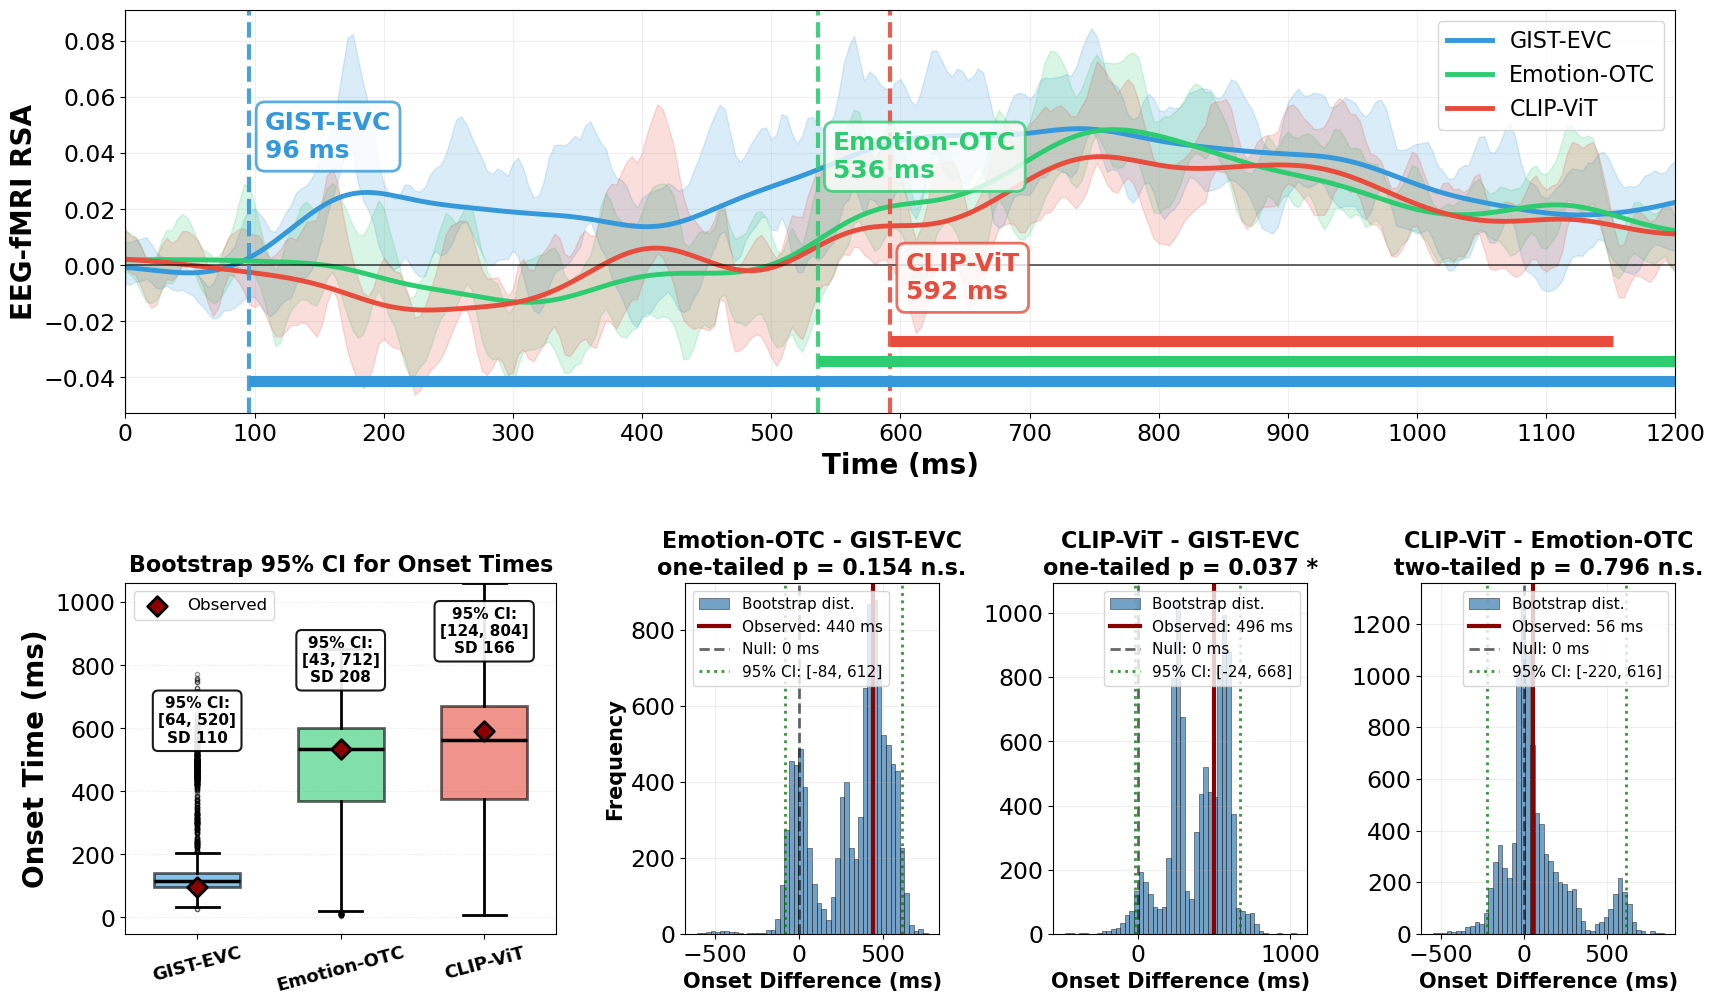

Saved combined figure to: onset_main_configurable_thr5_smooth10_min5_boot10000\combined_onset_figure_ABC.png


In [21]:
# ============================================================
# Combined publication figure: A (top, full width) + B/C (bottom row)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ---- Display-name mapping (figure labels only; upstream keys unchanged) ----
DISPLAY = {"GIST-EVC": "GIST-EVC", "Emotion-OTC": "Emotion-OTC", "Scene-ClipViT": "CLIP-ViT"}
def disp(name):
    return DISPLAY.get(name, name)
def disp_comparison(comp):
    # comp looks like "Scene-ClipViT - GIST-EVC"; relabel each side
    a, b = comp.split(" - ")
    return f"{disp(a)} - {disp(b)}"

# ---- Global font sizes (enlarged for print) ----
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 16,
})

fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(
    2, 3, figure=fig,
    height_ratios=[1.15, 1.0],
    hspace=0.45, wspace=0.30,   # slightly less vertical space between A and B/C
)

axA = fig.add_subplot(gs[0, :])      # top, full width
axB = fig.add_subplot(gs[1, 0])      # bottom-left
# Panel C: its own inner gridspec across columns 1-2 (three difference panels)
gsC = gridspec.GridSpecFromSubplotSpec(
    1, 3, subplot_spec=gs[1, 1:], wspace=0.45
)
axC = [fig.add_subplot(gsC[0, j]) for j in range(3)]

PANEL_LABEL_KW = dict(fontsize=30, fontweight="bold", va="top", ha="left")

# ============================================================
# PANEL A : RSA time courses + onsets
# ============================================================
plot_mask = (x_shifted >= test_window[0]) & (x_shifted <= test_window[1])
x_plot = x_shifted[plot_mask]

# stagger onset label boxes vertically so they don't overlap
label_y_frac = {"GIST-EVC": 0.75, "Emotion-OTC": 0.7, "Scene-ClipViT": 0.4}

for name in condition_names:
    res = onset_results[name]
    axA.plot(x_plot, res["smoothed_bc"][plot_mask],
             color=colors[name], linewidth=3.5, label=disp(name))
    axA.fill_between(
        x_plot,
        res["mean_curve_bc"][plot_mask] - res["sem_curve_bc"][plot_mask],
        res["mean_curve_bc"][plot_mask] + res["sem_curve_bc"][plot_mask],
        color=colors[name], alpha=0.18,
    )

axA.axhline(0, color="black", linewidth=1.2, alpha=0.7)

ymin, ymax = axA.get_ylim()
for name in condition_names:
    onset = onset_results[name]["onset_time"]
    if not np.isnan(onset):
        axA.axvline(onset, color=colors[name], linestyle="--", linewidth=3, alpha=0.9)
        axA.text(
            onset + 12, ymin + label_y_frac[name] * (ymax - ymin),
            f"{disp(name)}\n{onset:.0f} ms",
            color=colors[name], fontsize=18, fontweight="bold",
            va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                      edgecolor=colors[name], linewidth=2, alpha=0.8),
        )

# ---- Significance bars: horizontal lines over each significant cluster ----
yrange = ymax - ymin
bar_ys = {
    "GIST-EVC":      ymin + 0.08 * yrange,
    "Emotion-OTC":   ymin + 0.13 * yrange,
    "Scene-ClipViT": ymin + 0.18 * yrange,
}
for name in condition_names:
    for cl in onset_results[name]["clusters"]:
        x_cluster = x_shifted[cl]
        axA.plot(
            x_cluster,
            np.ones_like(x_cluster) * bar_ys[name],
            color=colors[name], linewidth=8, solid_capstyle="butt",
        )

# Stimulus-onset proxy entry in legend
axA.axvline(0, color="black", linewidth=1.6, alpha=0.6)

axA.set_xlim(test_window)
axA.set_xticks(np.arange(test_window[0], test_window[1] + 1, 100))  # 100 ms increments
axA.set_xlabel("Time (ms)", fontweight="bold")
axA.set_ylabel("EEG-fMRI RSA", fontweight="bold")
axA.legend(loc="upper right", frameon=True)
axA.grid(alpha=0.2)
# axA.text(-0.045, 1.02, "A", transform=axA.transAxes, **PANEL_LABEL_KW)

# ============================================================
# PANEL B : bootstrap onset boxplots
# ============================================================
onset_dists = [bootstrap_results[name]["valid_onsets"] for name in condition_names]

box = axB.boxplot(
    onset_dists, tick_labels=[disp(n) for n in condition_names], patch_artist=True, widths=0.6,
    showfliers=True,
    boxprops=dict(linewidth=2), whiskerprops=dict(linewidth=2),
    capprops=dict(linewidth=2), medianprops=dict(color="black", linewidth=2.5),
    flierprops=dict(marker="o", markersize=3, alpha=0.4),
)
for patch, name in zip(box["boxes"], condition_names):
    patch.set_facecolor(colors[name])
    patch.set_alpha(0.6)

observed = [onset_results[name]["onset_time"] for name in condition_names]
axB.scatter([1, 2, 3], observed, color="darkred", s=100, zorder=5,
            marker="D", edgecolors="black", linewidths=2, label="Observed")

for i, name in enumerate(condition_names):
    b = bootstrap_results[name]
    axB.text(
        i + 1, b["ci"][1] + 25,
        f"95% CI:\n[{b['ci'][0]:.0f}, {b['ci'][1]:.0f}]\nSD {b['sd']:.0f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                  edgecolor="black", alpha=0.9, linewidth=1.5),
    )

for lbl in axB.get_xticklabels():
    lbl.set_fontweight("bold")

_bmax = max(b["ci"][1] for b in bootstrap_results.values())
axB.set_title(
    "Bootstrap 95% CI for Onset Times",
    fontsize=16,
    fontweight="bold",
    pad=8,
)
axB.set_ylim(top=_bmax * 1.32)
axB.set_ylabel("Onset Time (ms)", fontweight="bold")
axB.legend(loc="upper left", frameon=True, fontsize=12)
axB.grid(axis="y", alpha=0.3, linestyle=":")
axB.tick_params(axis="x", labelrotation=15, labelsize=13)  # smaller B tick labels
# axB.text(-0.18, 1.02, "B", transform=axB.transAxes, **PANEL_LABEL_KW)

# ============================================================
# PANEL C : bootstrap onset-difference distributions
# ============================================================
one_tailed_later = ["Emotion-OTC - GIST-EVC", "Scene-ClipViT - GIST-EVC"]

for j, (key, result) in enumerate(bootstrap_diff_results.items()):
    ax = axC[j]
    diffs = result["diffs"]
    obs_diff = result["obs_diff"]
    ci = result["ci"]
    comparison = result["comparison"]

    if comparison in one_tailed_later:
        test_type = "one-tailed"
        p_value = np.mean(diffs <= 0)
    else:
        test_type = "two-tailed"
        p_value = min(2 * min(np.mean(diffs <= 0), np.mean(diffs >= 0)), 1.0)
    sig_marker = "*" if p_value < 0.05 else "n.s."

    ax.hist(diffs, bins=50, color="steelblue", alpha=0.75,
            edgecolor="black", linewidth=0.4, label="Bootstrap dist.")
    ax.axvline(obs_diff, color="darkred", linewidth=3,
               label=f"Observed: {obs_diff:.0f} ms")
    ax.axvline(0, color="black", linestyle="--", linewidth=2, alpha=0.6,
               label="Null: 0 ms")
    ax.axvline(ci[0], color="green", linestyle=":", linewidth=2, alpha=0.8)
    ax.axvline(ci[1], color="green", linestyle=":", linewidth=2, alpha=0.8,
               label=f"95% CI: [{ci[0]:.0f}, {ci[1]:.0f}]")

    ax.set_title(f"{disp_comparison(comparison)}\n{test_type} p = {p_value:.3f} {sig_marker}",
                 fontsize=16, fontweight="bold")
    ax.set_xlabel("Onset Difference (ms)", fontsize=15, fontweight="bold")
    if j == 0:
        ax.set_ylabel("Frequency", fontsize=15, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(alpha=0.2)

# axC[0].text(-0.22, 1.02, "C", transform=axC[0].transAxes, **PANEL_LABEL_KW)

# ============================================================
# Save
# ============================================================
os.makedirs(out_dir, exist_ok=True)
combined_path = os.path.join(out_dir, "combined_onset_figure_ABC.png")
fig.savefig(combined_path, dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "combined_onset_figure_ABC.pdf"), bbox_inches="tight")
plt.show()
print("Saved combined figure to:", combined_path)

# Add IQR

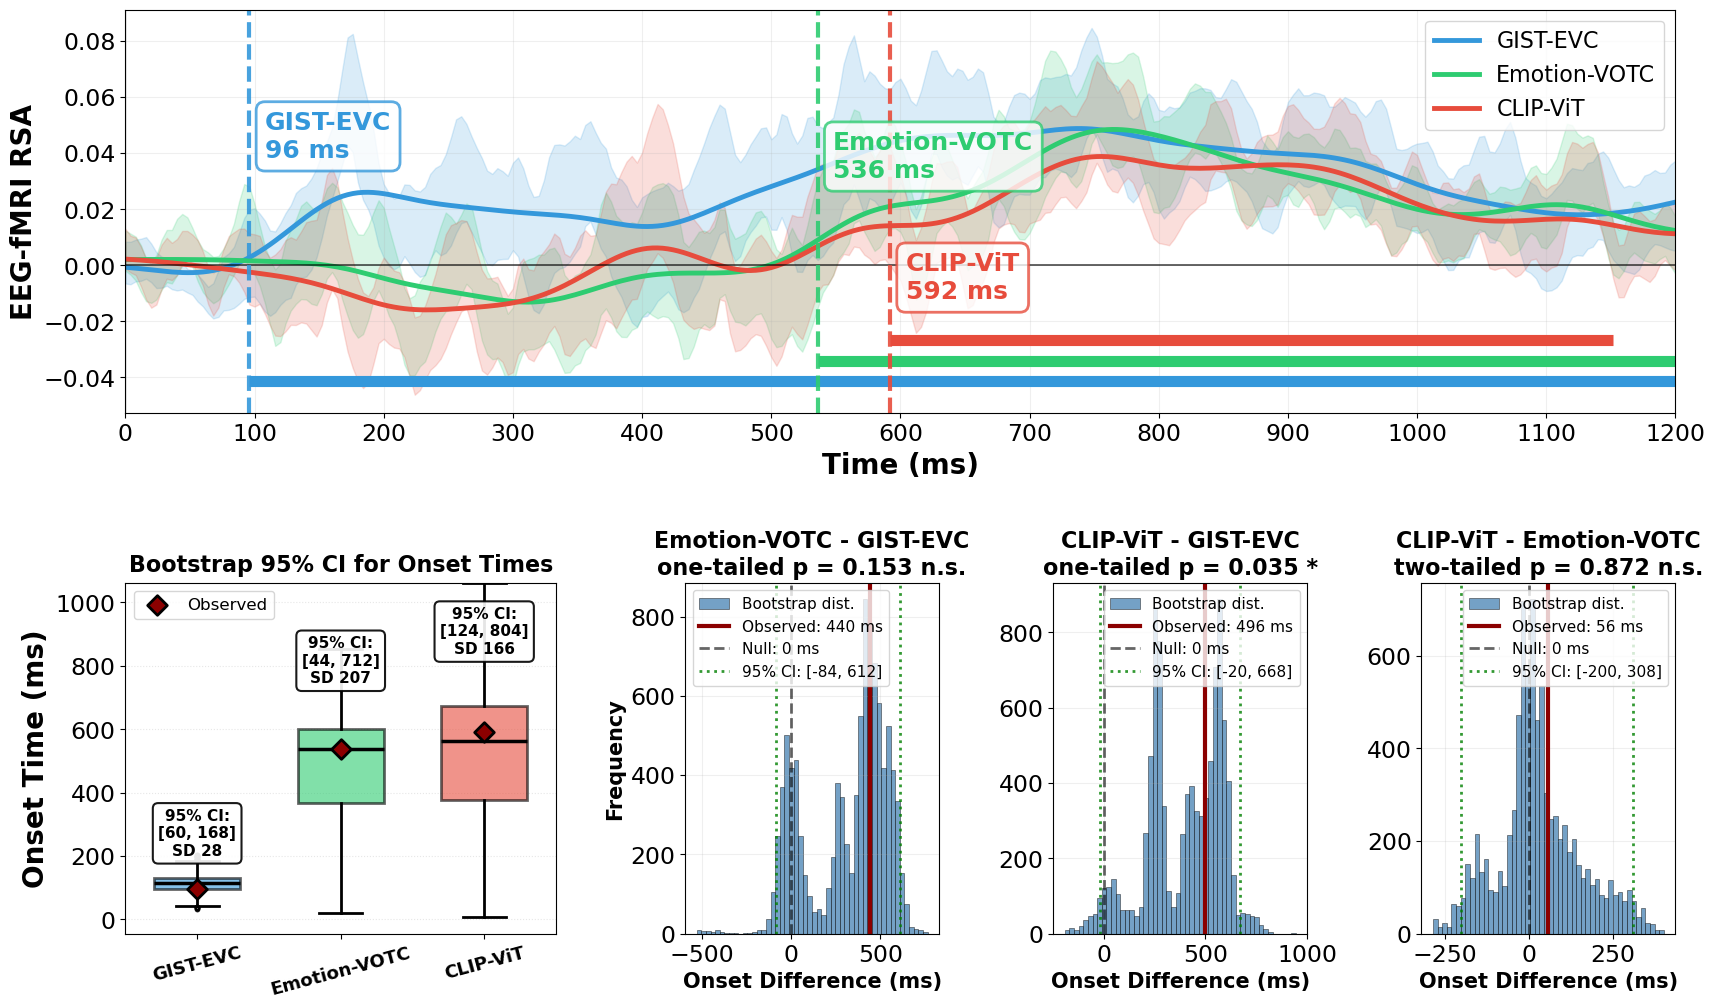

Saved combined figure to: onset_main_configurable_thr5_smooth10_min5_boot10000\combined_onset_figure_ABC.png


In [22]:


# ============================================================
# Combined publication figure: A (top, full width) + B/C (bottom row)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ---- Display-name mapping (figure labels only; upstream keys unchanged) ----
DISPLAY = {"GIST-EVC": "GIST-EVC", "Emotion-OTC": "Emotion-VOTC", "Scene-ClipViT": "CLIP-ViT"}
def disp(name):
    return DISPLAY.get(name, name)
def disp_comparison(comp):
    a, b = comp.split(" - ")
    return f"{disp(a)} - {disp(b)}"

# ---- IQR outlier removal (1.5x) ----
IQR_MULTIPLIER = 1.5
def remove_outliers_iqr(data, multiplier=IQR_MULTIPLIER):
    data = np.asarray(data)
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower, upper = q1 - multiplier * iqr, q3 + multiplier * iqr
    return data[(data >= lower) & (data <= upper)]

# ---- Global font sizes (enlarged for print) ----
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 16,
})

fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(
    2, 3, figure=fig,
    height_ratios=[1.15, 1.0],
    hspace=0.45, wspace=0.30,
)

axA = fig.add_subplot(gs[0, :])      # top, full width
axB = fig.add_subplot(gs[1, 0])      # bottom-left
gsC = gridspec.GridSpecFromSubplotSpec(
    1, 3, subplot_spec=gs[1, 1:], wspace=0.45
)
axC = [fig.add_subplot(gsC[0, j]) for j in range(3)]

PANEL_LABEL_KW = dict(fontsize=30, fontweight="bold", va="top", ha="left")

# ============================================================
# PANEL A : RSA time courses + onsets
# ============================================================
plot_mask = (x_shifted >= test_window[0]) & (x_shifted <= test_window[1])
x_plot = x_shifted[plot_mask]

label_y_frac = {"GIST-EVC": 0.75, "Emotion-OTC": 0.7, "Scene-ClipViT": 0.4}

for name in condition_names:
    res = onset_results[name]
    axA.plot(x_plot, res["smoothed_bc"][plot_mask],
             color=colors[name], linewidth=3.5, label=disp(name))
    axA.fill_between(
        x_plot,
        res["mean_curve_bc"][plot_mask] - res["sem_curve_bc"][plot_mask],
        res["mean_curve_bc"][plot_mask] + res["sem_curve_bc"][plot_mask],
        color=colors[name], alpha=0.18,
    )

# ---- Significance bars: horizontal lines over each significant cluster ----
yrange = ymax - ymin
bar_ys = {
    "GIST-EVC":      ymin + 0.08 * yrange,
    "Emotion-OTC":   ymin + 0.13 * yrange,
    "Scene-ClipViT": ymin + 0.18 * yrange,
}
for name in condition_names:
    for cl in onset_results[name]["clusters"]:
        x_cluster = x_shifted[cl]
        axA.plot(
            x_cluster,
            np.ones_like(x_cluster) * bar_ys[name],
            color=colors[name], linewidth=8, solid_capstyle="butt",
        )


axA.axhline(0, color="black", linewidth=1.2, alpha=0.7)

ymin, ymax = axA.get_ylim()
for name in condition_names:
    onset = onset_results[name]["onset_time"]
    if not np.isnan(onset):
        axA.axvline(onset, color=colors[name], linestyle="--", linewidth=3, alpha=0.9)
        axA.text(
            onset + 12, ymin + label_y_frac[name] * (ymax - ymin),
            f"{disp(name)}\n{onset:.0f} ms",
            color=colors[name], fontsize=18, fontweight="bold",
            va="top", ha="left",
            bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                      edgecolor=colors[name], linewidth=2, alpha=0.8),
        )

axA.axvline(0, color="black", linewidth=1.6, alpha=0.6)

axA.set_xlim(test_window)
axA.set_xticks(np.arange(test_window[0], test_window[1] + 1, 100))
axA.set_xlabel("Time (ms)", fontweight="bold")
axA.set_ylabel("EEG-fMRI RSA", fontweight="bold")
axA.legend(loc="upper right", frameon=True)
axA.grid(alpha=0.2)

# ============================================================
# PANEL B : bootstrap onset boxplots (IQR-cleaned)
# ============================================================
onset_dists = [remove_outliers_iqr(bootstrap_results[name]["valid_onsets"])
               for name in condition_names]

box = axB.boxplot(
    onset_dists, tick_labels=[disp(n) for n in condition_names], patch_artist=True, widths=0.6,
    showfliers=True,
    boxprops=dict(linewidth=2), whiskerprops=dict(linewidth=2),
    capprops=dict(linewidth=2), medianprops=dict(color="black", linewidth=2.5),
    flierprops=dict(marker="o", markersize=3, alpha=0.4),
)
for patch, name in zip(box["boxes"], condition_names):
    patch.set_facecolor(colors[name])
    patch.set_alpha(0.6)

observed = [onset_results[name]["onset_time"] for name in condition_names]
axB.scatter([1, 2, 3], observed, color="darkred", s=100, zorder=5,
            marker="D", edgecolors="black", linewidths=2, label="Observed")

for i, (name, dist) in enumerate(zip(condition_names, onset_dists)):
    ci_low, ci_high = np.percentile(dist, [2.5, 97.5])
    sd = dist.std(ddof=1)
    axB.text(
        i + 1, ci_high + 25,
        f"95% CI:\n[{ci_low:.0f}, {ci_high:.0f}]\nSD {sd:.0f}",
        ha="center", va="bottom", fontsize=11, fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                  edgecolor="black", alpha=0.9, linewidth=1.5),
    )

_bmax = max(np.percentile(d, 97.5) for d in onset_dists)
axB.set_title("Bootstrap 95% CI for Onset Times", fontsize=16, fontweight="bold", pad=8)
axB.set_ylim(top=_bmax * 1.32)
axB.set_ylabel("Onset Time (ms)", fontweight="bold")
axB.legend(loc="upper left", frameon=True, fontsize=12)
axB.grid(axis="y", alpha=0.3, linestyle=":")
axB.tick_params(axis="x", labelrotation=15, labelsize=13)
for lbl in axB.get_xticklabels():
    lbl.set_fontweight("bold")

# ============================================================
# PANEL C : bootstrap onset-difference distributions (IQR-cleaned)
# ============================================================
one_tailed_later = ["Emotion-OTC - GIST-EVC", "Scene-ClipViT - GIST-EVC"]

for j, (key, result) in enumerate(bootstrap_diff_results.items()):
    ax = axC[j]
    diffs = remove_outliers_iqr(result["diffs"])
    obs_diff = result["obs_diff"]
    ci = np.percentile(diffs, [2.5, 97.5])
    comparison = result["comparison"]

    if comparison in one_tailed_later:
        test_type = "one-tailed"
        p_value = np.mean(diffs <= 0)
    else:
        test_type = "two-tailed"
        p_value = min(2 * min(np.mean(diffs <= 0), np.mean(diffs >= 0)), 1.0)
    sig_marker = "*" if p_value < 0.05 else "n.s."

    ax.hist(diffs, bins=50, color="steelblue", alpha=0.75,
            edgecolor="black", linewidth=0.4, label="Bootstrap dist.")
    ax.axvline(obs_diff, color="darkred", linewidth=3,
               label=f"Observed: {obs_diff:.0f} ms")
    ax.axvline(0, color="black", linestyle="--", linewidth=2, alpha=0.6,
               label="Null: 0 ms")
    ax.axvline(ci[0], color="green", linestyle=":", linewidth=2, alpha=0.8)
    ax.axvline(ci[1], color="green", linestyle=":", linewidth=2, alpha=0.8,
               label=f"95% CI: [{ci[0]:.0f}, {ci[1]:.0f}]")

    ax.set_title(f"{disp_comparison(comparison)}\n{test_type} p = {p_value:.3f} {sig_marker}",
                 fontsize=16, fontweight="bold")
    ax.set_xlabel("Onset Difference (ms)", fontsize=15, fontweight="bold")
    if j == 0:
        ax.set_ylabel("Frequency", fontsize=15, fontweight="bold")
    ax.legend(fontsize=11)
    ax.grid(alpha=0.2)

# ============================================================
# Save
# ============================================================
os.makedirs(out_dir, exist_ok=True)
combined_path = os.path.join(out_dir, "combined_onset_figure_ABC.png")
fig.savefig(combined_path, dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "combined_onset_figure_ABC.pdf"), bbox_inches="tight")
plt.show()
print("Saved combined figure to:", combined_path)

In [23]:
import numpy as np

IQR_MULTIPLIER = 1.5
def remove_outliers_iqr(data, multiplier=IQR_MULTIPLIER):
    data = np.asarray(data, float)
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - multiplier * iqr, q3 + multiplier * iqr
    return data[(data >= lo) & (data <= hi)]

print(f"{'ROI':<14} {'onset':>6}  {'95% CI':>14}  {'SD':>5}   (n raw -> clean)")
print("-" * 60)
for name in condition_names:
    raw = np.asarray(bootstrap_results[name]["valid_onsets"], float)
    clean = remove_outliers_iqr(raw)
    ci_low, ci_high = np.percentile(clean, [2.5, 97.5])
    sd = clean.std(ddof=1)
    onset = onset_results[name]["onset_time"]
    print(f"{disp(name):<14} {onset:>6.0f}  [{ci_low:>4.0f}, {ci_high:>4.0f}]  {sd:>5.0f}   "
          f"({len(raw)} -> {len(clean)})")

ROI             onset          95% CI     SD   (n raw -> clean)
------------------------------------------------------------
GIST-EVC           96  [  60,  168]     28   (9996 -> 9055)
Emotion-VOTC      536  [  44,  712]    207   (9989 -> 9951)
CLIP-ViT          592  [ 124,  804]    166   (9619 -> 9618)


# Add pvalue correction to panel C

Emotion-OTC - GIST-EVC     raw p=0.153  Bonferroni p=0.458  n.s.
Scene-ClipViT - GIST-EVC   raw p=0.035  Bonferroni p=0.104  n.s.
Scene-ClipViT - Emotion-OTC raw p=0.872  Bonferroni p=1.000  n.s.


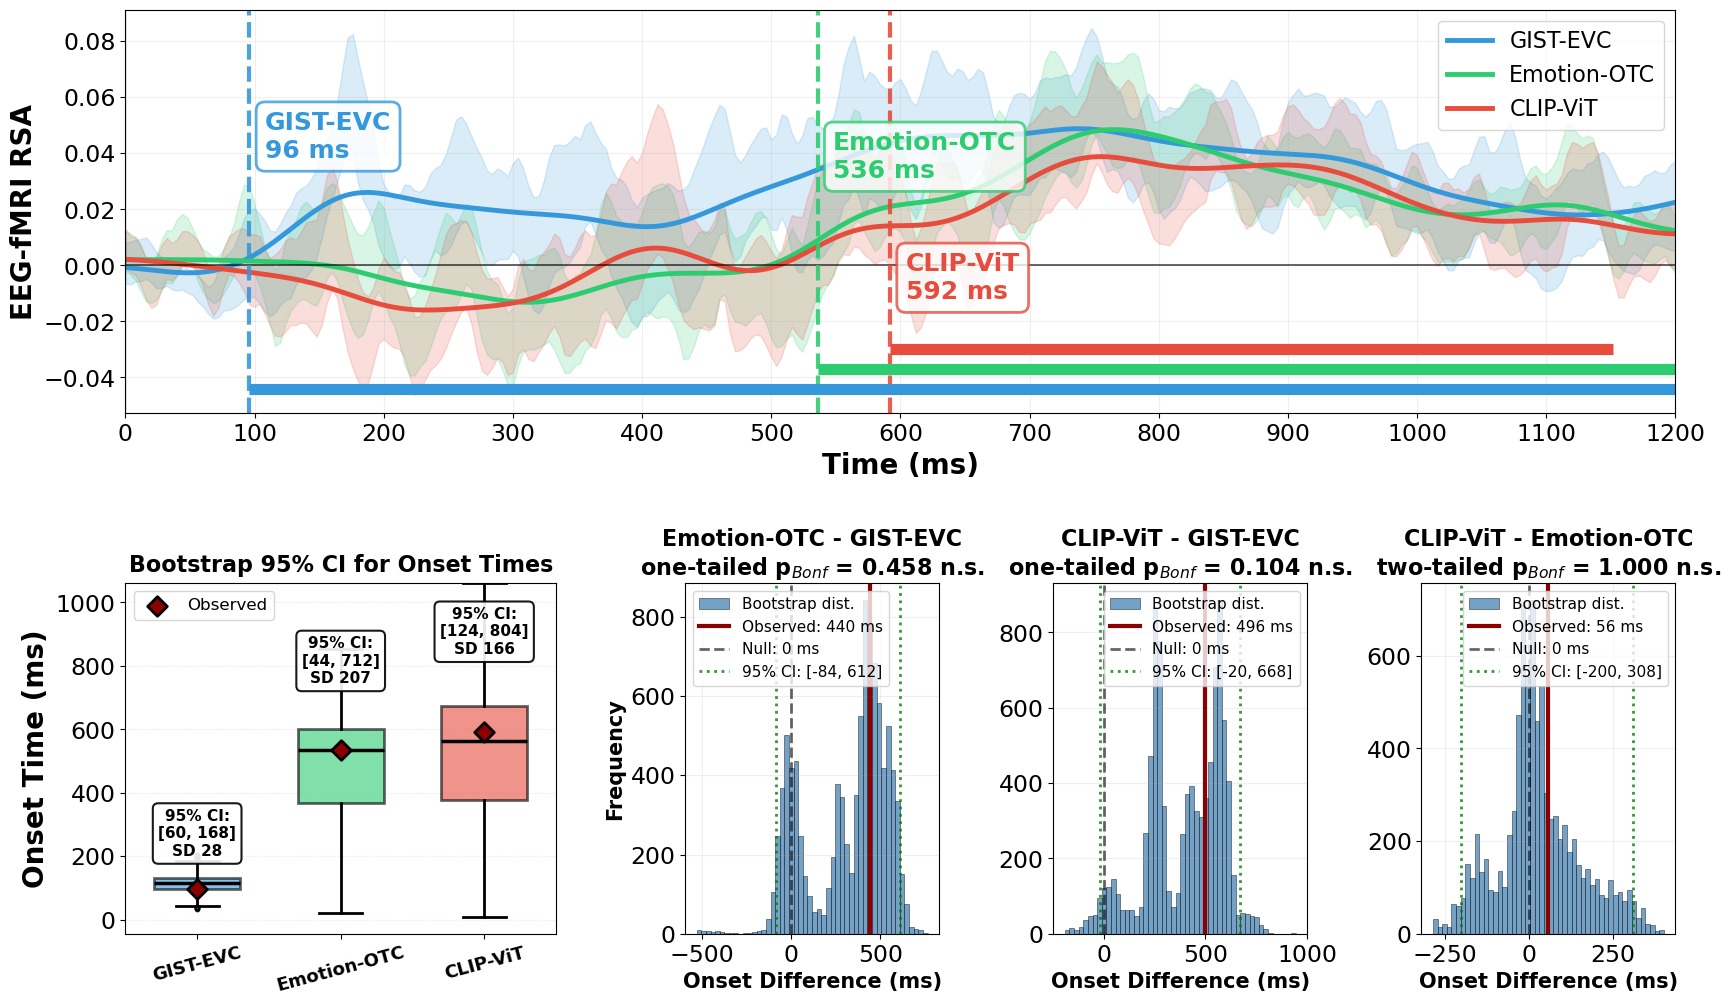

Saved: onset_main_configurable_thr5_smooth10_min5_boot10000\combined_onset_figure_bonferroni.png


In [24]:
# ============================================================
# All-in-one figure with Bonferroni-corrected bootstrap p-values
# Self-contained: recomputes onset-difference bootstraps from scratch.
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm

# ---- display names & correction settings ----
DISPLAY = {"GIST-EVC": "GIST-EVC", "Emotion-OTC": "Emotion-OTC", "Scene-ClipViT": "CLIP-ViT"}
def disp(n): return DISPLAY.get(n, n)
def disp_comparison(c):
    a, b = c.split(" - "); return f"{disp(a)} - {disp(b)}"

IQR_MULTIPLIER = 1.5
ALPHA = 0.05
def remove_outliers_iqr(data, multiplier=IQR_MULTIPLIER):
    data = np.asarray(data, float)
    q1, q3 = np.percentile(data, [25, 75]); iqr = q3 - q1
    lo, hi = q1 - multiplier * iqr, q3 + multiplier * iqr
    return data[(data >= lo) & (data <= hi)]

rsa_by_name = {"GIST-EVC": gistevc_rsa, "Emotion-OTC": behotc_rsa, "Scene-ClipViT": clipvit_rsa}

# ---- recompute onset-difference bootstraps (onset2 - onset1) ----
def boot_diff(rsa1, rsa2, seed=random_state, n=n_boot):
    rng = np.random.default_rng(seed)
    ns = rsa1.shape[0]
    diffs = []
    for _ in range(n):
        idx = rng.integers(0, ns, ns)
        r1 = preonset_onset_baseline_corrected(rsa1[idx], x_shifted,
              baseline_window=baseline_window, test_window=test_window,
              smooth_sigma=smooth_sigma, threshold_sigma=threshold_sigma,
              min_consecutive_samples=min_consecutive_samples)
        r2 = preonset_onset_baseline_corrected(rsa2[idx], x_shifted,
              baseline_window=baseline_window, test_window=test_window,
              smooth_sigma=smooth_sigma, threshold_sigma=threshold_sigma,
              min_consecutive_samples=min_consecutive_samples)
        o1, o2 = r1["onset_time"], r2["onset_time"]
        if not np.isnan(o1) and not np.isnan(o2):
            diffs.append(o2 - o1)
    return np.array(diffs, float)

# comparisons: (name1, name2, tail) ; diff = onset2 - onset1
comparisons = [
    ("GIST-EVC", "Emotion-OTC", "one-tailed"),
    ("GIST-EVC", "Scene-ClipViT", "one-tailed"),
    ("Emotion-OTC", "Scene-ClipViT", "two-tailed"),
]

diff_results, raw_p, tails, ckeys = {}, [], [], []
for n1, n2, tail in comparisons:
    diffs = boot_diff(rsa_by_name[n1], rsa_by_name[n2])
    diffs = remove_outliers_iqr(diffs)
    obs = onset_results[n2]["onset_time"] - onset_results[n1]["onset_time"]
    ci = np.percentile(diffs, [2.5, 97.5])
    if tail == "one-tailed":
        p = np.mean(diffs <= 0)
    else:
        p = min(2 * min(np.mean(diffs <= 0), np.mean(diffs >= 0)), 1.0)
    key = f"{n2} - {n1}"
    diff_results[key] = {"diffs": diffs, "obs": obs, "ci": ci, "tail": tail}
    ckeys.append(key); raw_p.append(p); tails.append(tail)

raw_p = np.array(raw_p)
p_bonf = np.minimum(raw_p * len(raw_p), 1.0)   # Bonferroni
for k, rp, bp in zip(ckeys, raw_p, p_bonf):
    print(f"{k:<26} raw p={rp:.3f}  Bonferroni p={bp:.3f}  {'*' if bp < ALPHA else 'n.s.'}")

# ============================================================
# FIGURE
# ============================================================
plt.rcParams.update({"font.size": 18, "axes.titlesize": 22, "axes.labelsize": 20,
                     "xtick.labelsize": 17, "ytick.labelsize": 17, "legend.fontsize": 16})

fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[1.15, 1.0], hspace=0.45, wspace=0.30)
axA = fig.add_subplot(gs[0, :])
axB = fig.add_subplot(gs[1, 0])
gsC = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[1, 1:], wspace=0.45)
axC = [fig.add_subplot(gsC[0, j]) for j in range(3)]

# --- Panel A ---
pmask = (x_shifted >= test_window[0]) & (x_shifted <= test_window[1])
xp = x_shifted[pmask]
label_y_frac = {"GIST-EVC": 0.75, "Emotion-OTC": 0.70, "Scene-ClipViT": 0.40}
for name in condition_names:
    r = onset_results[name]
    axA.plot(xp, r["smoothed_bc"][pmask], color=colors[name], linewidth=3.5, label=disp(name))
    axA.fill_between(xp, r["mean_curve_bc"][pmask] - r["sem_curve_bc"][pmask],
                     r["mean_curve_bc"][pmask] + r["sem_curve_bc"][pmask],
                     color=colors[name], alpha=0.18)
axA.axhline(0, color="black", linewidth=1.2, alpha=0.7)
ymin, ymax = axA.get_ylim()
for name in condition_names:
    o = onset_results[name]["onset_time"]
    if not np.isnan(o):
        axA.axvline(o, color=colors[name], linestyle="--", linewidth=3, alpha=0.9)
        axA.text(o + 12, ymin + label_y_frac[name] * (ymax - ymin), f"{disp(name)}\n{o:.0f} ms",
                 color=colors[name], fontsize=18, fontweight="bold", va="top", ha="left",
                 bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                           edgecolor=colors[name], linewidth=2, alpha=0.8))
# significance/cluster bars
yrange = ymax - ymin
bar_ys = {"GIST-EVC": ymin + 0.06 * yrange, "Emotion-OTC": ymin + 0.11 * yrange,
          "Scene-ClipViT": ymin + 0.16 * yrange}
for name in condition_names:
    for cl in onset_results[name].get("clusters", []):
        seg = cl[(x_shifted[cl] >= test_window[0]) & (x_shifted[cl] <= test_window[1])]
        if len(seg):
            axA.plot(x_shifted[seg], np.full(len(seg), bar_ys[name]),
                     color=colors[name], linewidth=8, solid_capstyle="butt")
axA.axvline(0, color="black", linewidth=1.6, alpha=0.6)
axA.set_xlim(test_window); axA.set_ylim(ymin, ymax)
axA.set_xticks(np.arange(test_window[0], test_window[1] + 1, 100))
axA.set_xlabel("Time (ms)", fontweight="bold")
axA.set_ylabel("EEG-fMRI RSA", fontweight="bold")
axA.legend(loc="upper right", frameon=True); axA.grid(alpha=0.2)

# --- Panel B (IQR-cleaned onsets) ---
onset_dists = [remove_outliers_iqr(bootstrap_results[n]["valid_onsets"]) for n in condition_names]
box = axB.boxplot(onset_dists, tick_labels=[disp(n) for n in condition_names], patch_artist=True,
                  widths=0.6, showfliers=True, boxprops=dict(linewidth=2),
                  whiskerprops=dict(linewidth=2), capprops=dict(linewidth=2),
                  medianprops=dict(color="black", linewidth=2.5),
                  flierprops=dict(marker="o", markersize=3, alpha=0.4))
for patch, name in zip(box["boxes"], condition_names):
    patch.set_facecolor(colors[name]); patch.set_alpha(0.6)
observed = [onset_results[n]["onset_time"] for n in condition_names]
axB.scatter([1, 2, 3], observed, color="darkred", s=100, zorder=5, marker="D",
            edgecolors="black", linewidths=2, label="Observed")
for i, (name, dist) in enumerate(zip(condition_names, onset_dists)):
    lo, hi = np.percentile(dist, [2.5, 97.5]); sd = dist.std(ddof=1)
    axB.text(i + 1, hi + 25, f"95% CI:\n[{lo:.0f}, {hi:.0f}]\nSD {sd:.0f}",
             ha="center", va="bottom", fontsize=11, fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                       edgecolor="black", alpha=0.9, linewidth=1.5))
axB.set_ylim(top=max(np.percentile(d, 97.5) for d in onset_dists) * 1.32)
axB.set_title("Bootstrap 95% CI for Onset Times", fontsize=16, fontweight="bold", pad=8)
axB.set_ylabel("Onset Time (ms)", fontweight="bold")
axB.legend(loc="upper left", frameon=True, fontsize=12)
axB.grid(axis="y", alpha=0.3, linestyle=":")
axB.tick_params(axis="x", labelrotation=15, labelsize=13)
for lbl in axB.get_xticklabels():
    lbl.set_fontweight("bold")

# --- Panel C (Bonferroni-corrected p) ---
for j, key in enumerate(ckeys):
    ax = axC[j]; res = diff_results[key]
    diffs, obs, ci, tail = res["diffs"], res["obs"], res["ci"], res["tail"]
    p_corr = p_bonf[j]
    sig = "*" if p_corr < ALPHA else "n.s."
    ax.hist(diffs, bins=50, color="steelblue", alpha=0.75, edgecolor="black",
            linewidth=0.4, label="Bootstrap dist.")
    ax.axvline(obs, color="darkred", linewidth=3, label=f"Observed: {obs:.0f} ms")
    ax.axvline(0, color="black", linestyle="--", linewidth=2, alpha=0.6, label="Null: 0 ms")
    ax.axvline(ci[0], color="green", linestyle=":", linewidth=2, alpha=0.8)
    ax.axvline(ci[1], color="green", linestyle=":", linewidth=2, alpha=0.8,
               label=f"95% CI: [{ci[0]:.0f}, {ci[1]:.0f}]")
    ax.set_title(f"{disp_comparison(key)}\n{tail} p$_{{Bonf}}$ = {p_corr:.3f} {sig}",
                 fontsize=16, fontweight="bold")
    ax.set_xlabel("Onset Difference (ms)", fontsize=15, fontweight="bold")
    if j == 0:
        ax.set_ylabel("Frequency", fontsize=15, fontweight="bold")
    ax.legend(fontsize=11); ax.grid(alpha=0.2)

os.makedirs(out_dir, exist_ok=True)
out_png = os.path.join(out_dir, "combined_onset_figure_bonferroni.png")
fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "combined_onset_figure_bonferroni.pdf"), bbox_inches="tight")
plt.show()
print("Saved:", out_png)

# Change to permutation to panel c

Emotion-OTC - GIST-EVC: obs=440 ms | bootstrap CI [-84, 612] | permutation p=0.089 (one-tailed, null n=10000)


Scene-ClipViT - GIST-EVC: obs=496 ms | bootstrap CI [-20, 668] | permutation p=0.013 (one-tailed, null n=10000)


Scene-ClipViT - Emotion-OTC: obs=56 ms | bootstrap CI [-200, 308] | permutation p=0.506 (two-tailed, null n=10000)


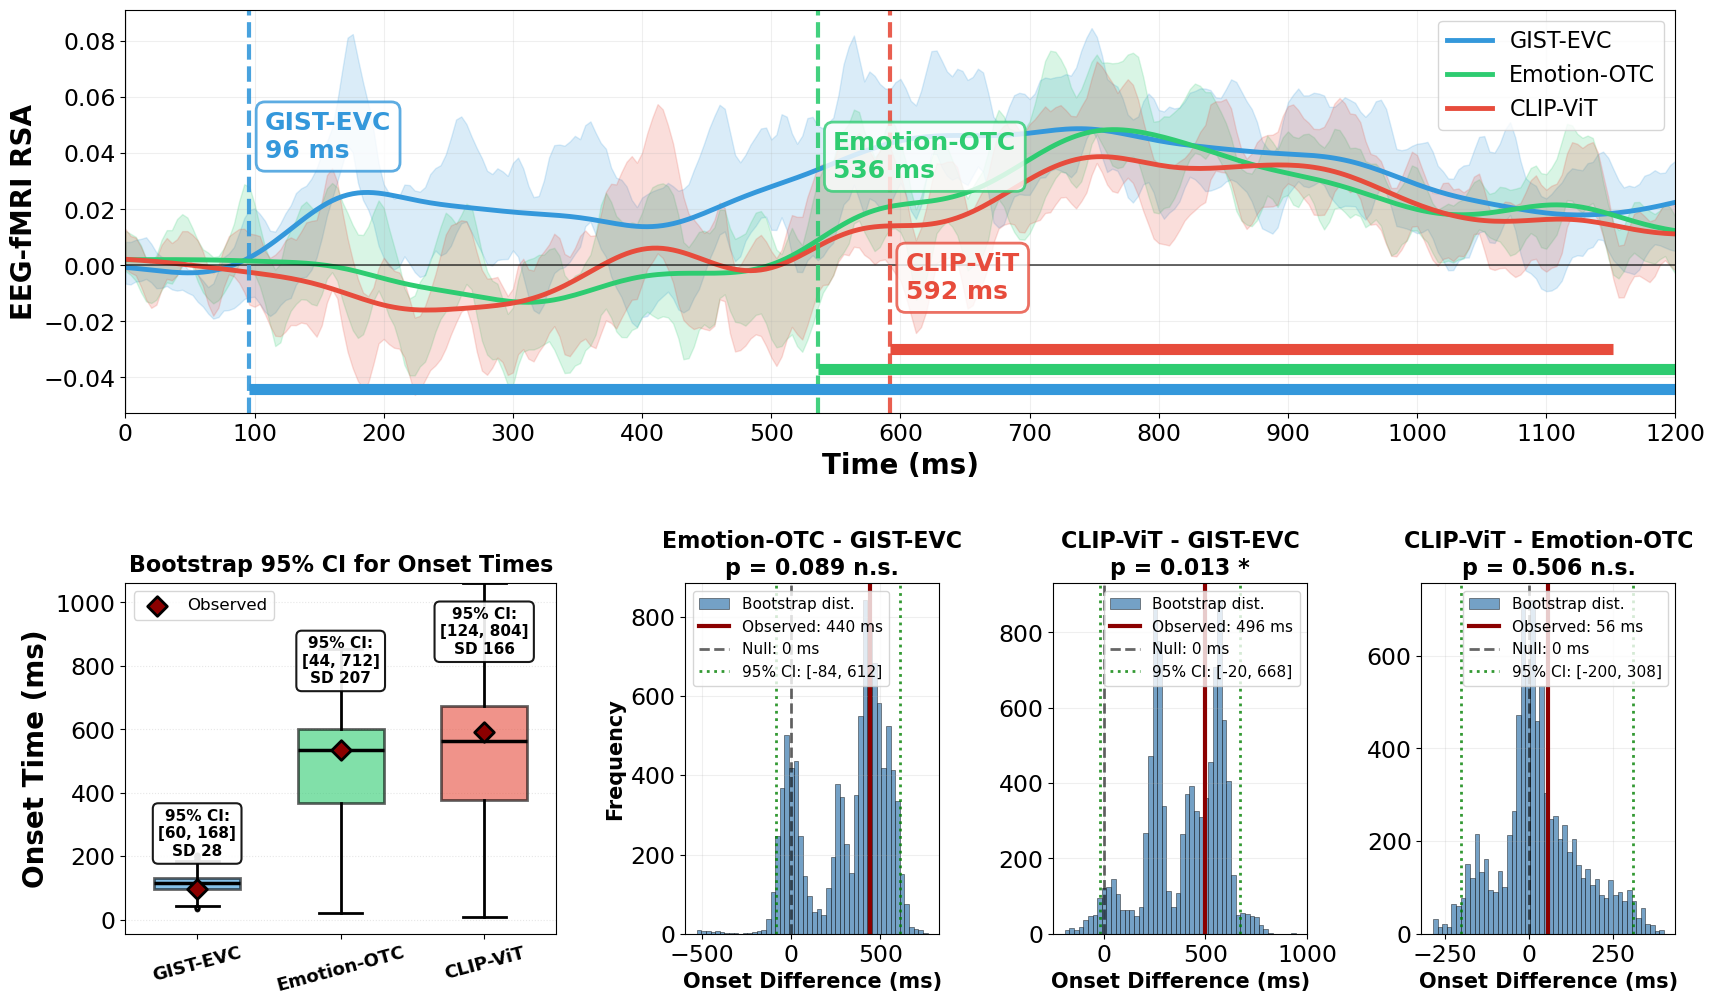

Saved: onset_main_configurable_thr5_smooth10_min5_boot10000\combined_onset_figure_perm_p.png


In [29]:
# ============================================================
# Panel C, option 2: bootstrap histogram + CI, but PERMUTATION p-value
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm

DISPLAY = {"GIST-EVC": "GIST-EVC", "Emotion-OTC": "Emotion-OTC", "Scene-ClipViT": "CLIP-ViT"}
def disp(n): return DISPLAY.get(n, n)
def disp_comparison(c):
    a, b = c.split(" - "); return f"{disp(a)} - {disp(b)}"

IQR_MULTIPLIER = 1.5
ALPHA = 0.05
def remove_outliers_iqr(data, multiplier=IQR_MULTIPLIER):
    data = np.asarray(data, float)
    q1, q3 = np.percentile(data, [25, 75]); iqr = q3 - q1
    lo, hi = q1 - multiplier * iqr, q3 + multiplier * iqr
    return data[(data >= lo) & (data <= hi)]

rsa_by_name = {"GIST-EVC": gistevc_rsa, "Emotion-OTC": behotc_rsa, "Scene-ClipViT": clipvit_rsa}

# comparisons: (name1, name2, tail) ; diff = onset2 - onset1
comparisons = [
    ("GIST-EVC", "Emotion-OTC", "one-tailed"),
    ("GIST-EVC", "Scene-ClipViT", "one-tailed"),
    ("Emotion-OTC", "Scene-ClipViT", "two-tailed"),
]

def _onset(rsa_subset):
    return preonset_onset_baseline_corrected(
        rsa_subset, x_shifted,
        baseline_window=baseline_window, test_window=test_window,
        smooth_sigma=smooth_sigma, threshold_sigma=threshold_sigma,
        min_consecutive_samples=min_consecutive_samples,
    )["onset_time"]

# ---- bootstrap difference (for histogram + CI) ----
def boot_diff(rsa1, rsa2, seed=random_state, n=n_boot):
    rng = np.random.default_rng(seed); ns = rsa1.shape[0]; out = []
    for _ in range(n):
        idx = rng.integers(0, ns, ns)
        o1, o2 = _onset(rsa1[idx]), _onset(rsa2[idx])
        if not np.isnan(o1) and not np.isnan(o2):
            out.append(o2 - o1)
    return np.array(out, float)

# ---- PERMUTATION null (for p-value): within-subject 2-way label swap ----
def perm_null(rsa1, rsa2, seed=random_state, n=n_boot):
    rng = np.random.default_rng(seed + 1); ns = rsa1.shape[0]
    stack = np.stack([rsa1, rsa2], axis=1)   # (ns, 2, T)
    null = []
    for _ in tqdm(range(n), desc="perm", ncols=70, leave=False):
        swap = rng.random(ns) < 0.5
        p = stack.copy()
        p[swap] = stack[swap][:, ::-1]       # swap the two labels within those subjects
        o1, o2 = _onset(p[:, 0]), _onset(p[:, 1])
        if not np.isnan(o1) and not np.isnan(o2):
            null.append(o2 - o1)
    return np.array(null, float)

panelC = {}
for n1, n2, tail in comparisons:
    key = f"{n2} - {n1}"
    obs = onset_results[n2]["onset_time"] - onset_results[n1]["onset_time"]

    # bootstrap: histogram + CI (unchanged from your version)
    bdiffs = remove_outliers_iqr(boot_diff(rsa_by_name[n1], rsa_by_name[n2]))
    ci = np.percentile(bdiffs, [2.5, 97.5])

    # permutation: p-value only
    null = perm_null(rsa_by_name[n1], rsa_by_name[n2])
    if tail == "one-tailed":
        p = np.mean(null >= obs)                       # H1: onset2 later than onset1
    else:
        p = np.mean(np.abs(null) >= np.abs(obs))
    panelC[key] = {"bdiffs": bdiffs, "ci": ci, "obs": obs, "p": p, "tail": tail}
    print(f"{key}: obs={obs:.0f} ms | bootstrap CI [{ci[0]:.0f}, {ci[1]:.0f}] | "
          f"permutation p={p:.3f} ({tail}, null n={len(null)})")

# ============================================================
# FIGURE (A and B identical to your current version; C uses perm p-value)
# ============================================================
plt.rcParams.update({"font.size": 18, "axes.titlesize": 22, "axes.labelsize": 20,
                     "xtick.labelsize": 17, "ytick.labelsize": 17, "legend.fontsize": 16})

fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[1.15, 1.0], hspace=0.45, wspace=0.30)
axA = fig.add_subplot(gs[0, :])
axB = fig.add_subplot(gs[1, 0])
gsC = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[1, 1:], wspace=0.45)
axC = [fig.add_subplot(gsC[0, j]) for j in range(3)]

# --- Panel A ---
pmask = (x_shifted >= test_window[0]) & (x_shifted <= test_window[1]); xp = x_shifted[pmask]
label_y_frac = {"GIST-EVC": 0.75, "Emotion-OTC": 0.70, "Scene-ClipViT": 0.40}
for name in condition_names:
    r = onset_results[name]
    axA.plot(xp, r["smoothed_bc"][pmask], color=colors[name], linewidth=3.5, label=disp(name))
    axA.fill_between(xp, r["mean_curve_bc"][pmask] - r["sem_curve_bc"][pmask],
                     r["mean_curve_bc"][pmask] + r["sem_curve_bc"][pmask],
                     color=colors[name], alpha=0.18)
axA.axhline(0, color="black", linewidth=1.2, alpha=0.7)
ymin, ymax = axA.get_ylim()
for name in condition_names:
    o = onset_results[name]["onset_time"]
    if not np.isnan(o):
        axA.axvline(o, color=colors[name], linestyle="--", linewidth=3, alpha=0.9)
        axA.text(o + 12, ymin + label_y_frac[name] * (ymax - ymin), f"{disp(name)}\n{o:.0f} ms",
                 color=colors[name], fontsize=18, fontweight="bold", va="top", ha="left",
                 bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                           edgecolor=colors[name], linewidth=2, alpha=0.8))
yrange = ymax - ymin
bar_ys = {"GIST-EVC": ymin + 0.06 * yrange, "Emotion-OTC": ymin + 0.11 * yrange,
          "Scene-ClipViT": ymin + 0.16 * yrange}
for name in condition_names:
    for cl in onset_results[name].get("clusters", []):
        seg = cl[(x_shifted[cl] >= test_window[0]) & (x_shifted[cl] <= test_window[1])]
        if len(seg):
            axA.plot(x_shifted[seg], np.full(len(seg), bar_ys[name]),
                     color=colors[name], linewidth=8, solid_capstyle="butt")
axA.axvline(0, color="black", linewidth=1.6, alpha=0.6)
axA.set_xlim(test_window); axA.set_ylim(ymin, ymax)
axA.set_xticks(np.arange(test_window[0], test_window[1] + 1, 100))
axA.set_xlabel("Time (ms)", fontweight="bold"); axA.set_ylabel("EEG-fMRI RSA", fontweight="bold")
axA.legend(loc="upper right", frameon=True); axA.grid(alpha=0.2)

# --- Panel B ---
onset_dists = [remove_outliers_iqr(bootstrap_results[n]["valid_onsets"]) for n in condition_names]
box = axB.boxplot(onset_dists, tick_labels=[disp(n) for n in condition_names], patch_artist=True,
                  widths=0.6, showfliers=True, boxprops=dict(linewidth=2),
                  whiskerprops=dict(linewidth=2), capprops=dict(linewidth=2),
                  medianprops=dict(color="black", linewidth=2.5),
                  flierprops=dict(marker="o", markersize=3, alpha=0.4))
for patch, name in zip(box["boxes"], condition_names):
    patch.set_facecolor(colors[name]); patch.set_alpha(0.6)
observed = [onset_results[n]["onset_time"] for n in condition_names]
axB.scatter([1, 2, 3], observed, color="darkred", s=100, zorder=5, marker="D",
            edgecolors="black", linewidths=2, label="Observed")
for i, (name, dist) in enumerate(zip(condition_names, onset_dists)):
    lo, hi = np.percentile(dist, [2.5, 97.5]); sd = dist.std(ddof=1)
    axB.text(i + 1, hi + 25, f"95% CI:\n[{lo:.0f}, {hi:.0f}]\nSD {sd:.0f}",
             ha="center", va="bottom", fontsize=11, fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                       edgecolor="black", alpha=0.9, linewidth=1.5))
axB.set_ylim(top=max(np.percentile(d, 97.5) for d in onset_dists) * 1.32)
axB.set_title("Bootstrap 95% CI for Onset Times", fontsize=16, fontweight="bold", pad=8)
axB.set_ylabel("Onset Time (ms)", fontweight="bold")
axB.legend(loc="upper left", frameon=True, fontsize=12)
axB.grid(axis="y", alpha=0.3, linestyle=":")
axB.tick_params(axis="x", labelrotation=15, labelsize=13)
for lbl in axB.get_xticklabels():
    lbl.set_fontweight("bold")

# --- Panel C: bootstrap histogram + CI, PERMUTATION p-value ---
for j, key in enumerate(panelC):
    ax = axC[j]; res = panelC[key]
    diffs, ci, obs, p, tail = res["bdiffs"], res["ci"], res["obs"], res["p"], res["tail"]
    sig = "*" if p < ALPHA else "n.s."
    ax.hist(diffs, bins=50, color="steelblue", alpha=0.75, edgecolor="black",
            linewidth=0.4, label="Bootstrap dist.")
    ax.axvline(obs, color="darkred", linewidth=3, label=f"Observed: {obs:.0f} ms")
    ax.axvline(0, color="black", linestyle="--", linewidth=2, alpha=0.6, label="Null: 0 ms")
    ax.axvline(ci[0], color="green", linestyle=":", linewidth=2, alpha=0.8)
    ax.axvline(ci[1], color="green", linestyle=":", linewidth=2, alpha=0.8,
               label=f"95% CI: [{ci[0]:.0f}, {ci[1]:.0f}]")
    ax.set_title(f"{disp_comparison(key)}\np = {p:.3f} {sig}",
                 fontsize=16, fontweight="bold")
    ax.set_xlabel("Onset Difference (ms)", fontsize=15, fontweight="bold")
    if j == 0:
        ax.set_ylabel("Frequency", fontsize=15, fontweight="bold")
    ax.legend(fontsize=11); ax.grid(alpha=0.2)

os.makedirs(out_dir, exist_ok=True)
out_png = os.path.join(out_dir, "combined_onset_figure_perm_p.png")
fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "combined_onset_figure_perm_p.pdf"), bbox_inches="tight")
plt.show()
print("Saved:", out_png)

# Add p value correction for permutation

Bonferroni correction across 3 comparisons (alpha = 0.05 ):
  Emotion-OTC - GIST-EVC     raw p=0.089  Bonferroni p=0.267  n.s.
  Scene-ClipViT - GIST-EVC   raw p=0.013  Bonferroni p=0.039  *
  Scene-ClipViT - Emotion-OTC raw p=0.506  Bonferroni p=1.000  n.s.


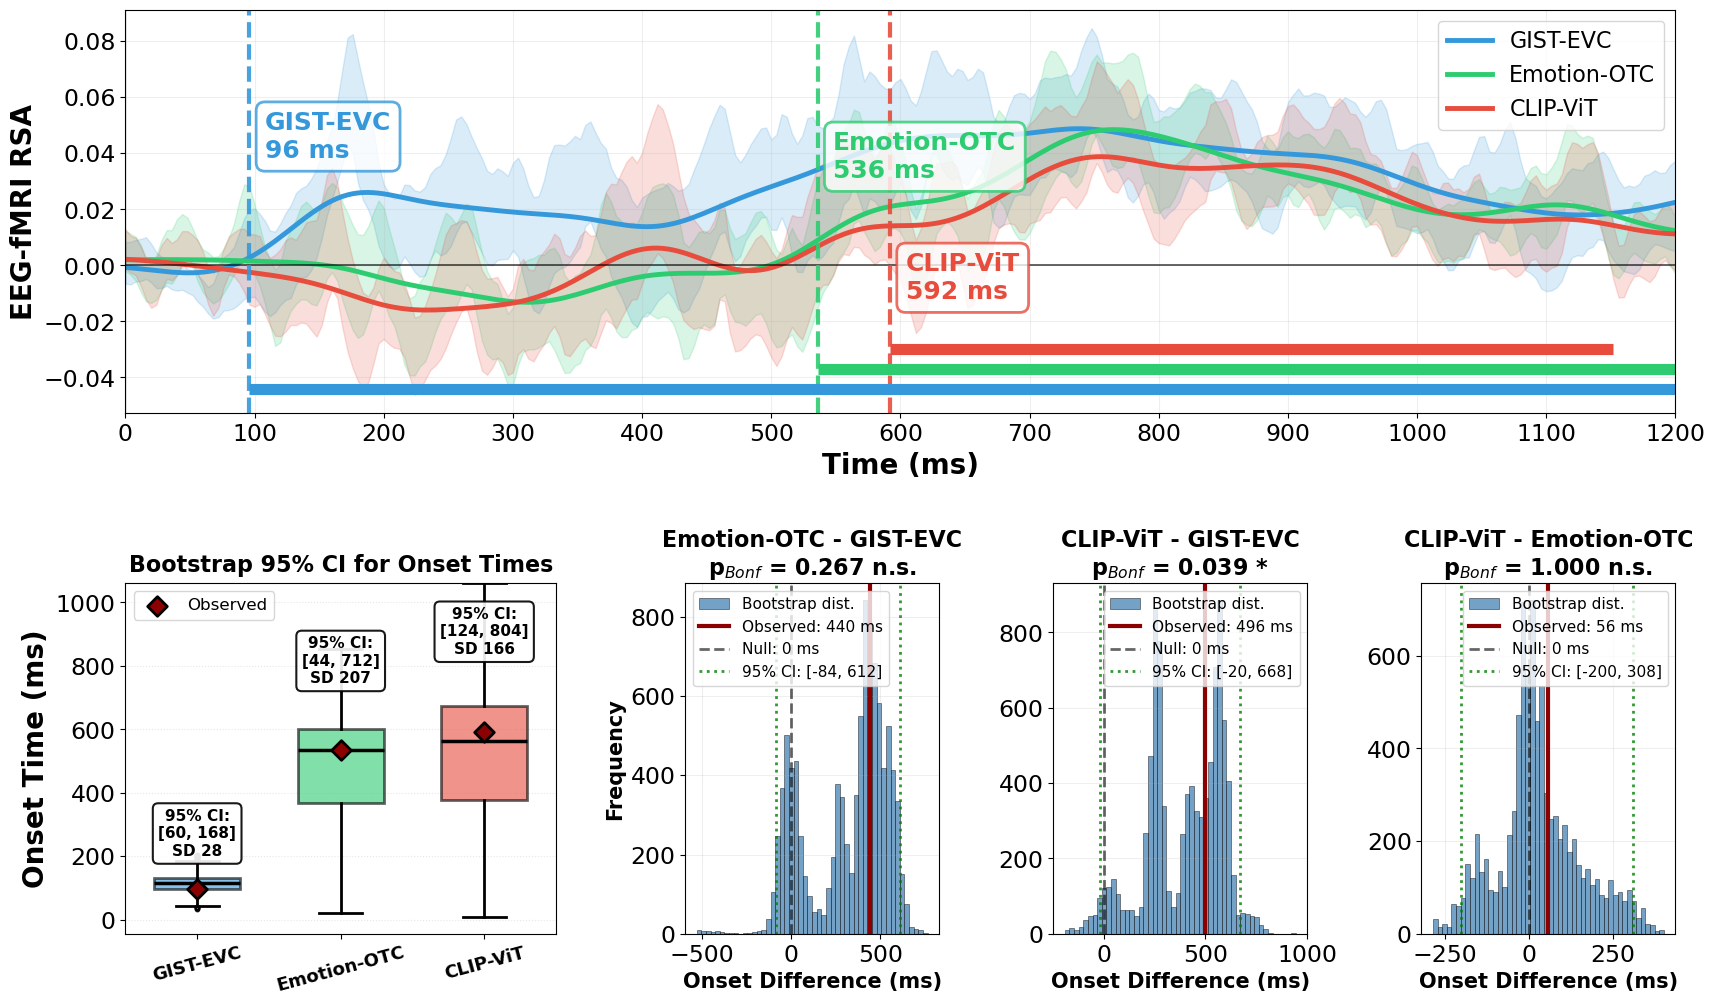

Saved: onset_main_configurable_thr5_smooth10_min5_boot10000\combined_onset_figure_bonf_perm.png


In [31]:
# ============================================================
# Panel C: bootstrap histogram + CI, permutation p-value, Bonferroni-corrected
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm

DISPLAY = {"GIST-EVC": "GIST-EVC", "Emotion-OTC": "Emotion-OTC", "Scene-ClipViT": "CLIP-ViT"}
def disp(n): return DISPLAY.get(n, n)
def disp_comparison(c):
    a, b = c.split(" - "); return f"{disp(a)} - {disp(b)}"

IQR_MULTIPLIER = 1.5
ALPHA = 0.05
def remove_outliers_iqr(data, multiplier=IQR_MULTIPLIER):
    data = np.asarray(data, float)
    q1, q3 = np.percentile(data, [25, 75]); iqr = q3 - q1
    lo, hi = q1 - multiplier * iqr, q3 + multiplier * iqr
    return data[(data >= lo) & (data <= hi)]

rsa_by_name = {"GIST-EVC": gistevc_rsa, "Emotion-OTC": behotc_rsa, "Scene-ClipViT": clipvit_rsa}

# comparisons: (name1, name2, tail) ; diff = onset2 - onset1
comparisons = [
    ("GIST-EVC", "Emotion-OTC", "one-tailed"),
    ("GIST-EVC", "Scene-ClipViT", "one-tailed"),
    ("Emotion-OTC", "Scene-ClipViT", "two-tailed"),
]

def _onset(rsa_subset):
    return preonset_onset_baseline_corrected(
        rsa_subset, x_shifted,
        baseline_window=baseline_window, test_window=test_window,
        smooth_sigma=smooth_sigma, threshold_sigma=threshold_sigma,
        min_consecutive_samples=min_consecutive_samples,
    )["onset_time"]

# ---- bootstrap difference (histogram + CI) ----
def boot_diff(rsa1, rsa2, seed=random_state, n=n_boot):
    rng = np.random.default_rng(seed); ns = rsa1.shape[0]; out = []
    for _ in range(n):
        idx = rng.integers(0, ns, ns)
        o1, o2 = _onset(rsa1[idx]), _onset(rsa2[idx])
        if not np.isnan(o1) and not np.isnan(o2):
            out.append(o2 - o1)
    return np.array(out, float)

# ---- permutation null (p-value): within-subject 2-way label swap ----
def perm_null(rsa1, rsa2, seed=random_state, n=n_boot):
    rng = np.random.default_rng(seed + 1); ns = rsa1.shape[0]
    stack = np.stack([rsa1, rsa2], axis=1)   # (ns, 2, T)
    null = []
    for _ in tqdm(range(n), desc="perm", ncols=70, leave=False):
        swap = rng.random(ns) < 0.5
        p = stack.copy()
        p[swap] = stack[swap][:, ::-1]
        o1, o2 = _onset(p[:, 0]), _onset(p[:, 1])
        if not np.isnan(o1) and not np.isnan(o2):
            null.append(o2 - o1)
    return np.array(null, float)

# ---- compute raw p, then Bonferroni-correct ----
panelC = {}
raw_p, pkeys = [], []
for n1, n2, tail in comparisons:
    key = f"{n2} - {n1}"
    obs = onset_results[n2]["onset_time"] - onset_results[n1]["onset_time"]

    bdiffs = remove_outliers_iqr(boot_diff(rsa_by_name[n1], rsa_by_name[n2]))
    ci = np.percentile(bdiffs, [2.5, 97.5])

    null = perm_null(rsa_by_name[n1], rsa_by_name[n2])
    if tail == "one-tailed":
        p = np.mean(null >= obs)
    else:
        p = np.mean(np.abs(null) >= np.abs(obs))

    panelC[key] = {"bdiffs": bdiffs, "ci": ci, "obs": obs, "tail": tail}
    raw_p.append(p); pkeys.append(key)

n_comp = len(raw_p)
print("Bonferroni correction across", n_comp, "comparisons (alpha =", ALPHA, "):")
for key, p in zip(pkeys, raw_p):
    p_corr = min(p * n_comp, 1.0)
    panelC[key]["p_raw"] = p
    panelC[key]["p"] = p_corr
    print(f"  {key:<26} raw p={p:.3f}  Bonferroni p={p_corr:.3f}  "
          f"{'*' if p_corr < ALPHA else 'n.s.'}")

# ============================================================
# FIGURE
# ============================================================
plt.rcParams.update({"font.size": 18, "axes.titlesize": 22, "axes.labelsize": 20,
                     "xtick.labelsize": 17, "ytick.labelsize": 17, "legend.fontsize": 16})

fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[1.15, 1.0], hspace=0.45, wspace=0.30)
axA = fig.add_subplot(gs[0, :])
axB = fig.add_subplot(gs[1, 0])
gsC = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=gs[1, 1:], wspace=0.45)
axC = [fig.add_subplot(gsC[0, j]) for j in range(3)]

# --- Panel A ---
pmask = (x_shifted >= test_window[0]) & (x_shifted <= test_window[1]); xp = x_shifted[pmask]
label_y_frac = {"GIST-EVC": 0.75, "Emotion-OTC": 0.70, "Scene-ClipViT": 0.40}
for name in condition_names:
    r = onset_results[name]
    axA.plot(xp, r["smoothed_bc"][pmask], color=colors[name], linewidth=3.5, label=disp(name))
    axA.fill_between(xp, r["mean_curve_bc"][pmask] - r["sem_curve_bc"][pmask],
                     r["mean_curve_bc"][pmask] + r["sem_curve_bc"][pmask],
                     color=colors[name], alpha=0.18)
axA.axhline(0, color="black", linewidth=1.2, alpha=0.7)
ymin, ymax = axA.get_ylim()
for name in condition_names:
    o = onset_results[name]["onset_time"]
    if not np.isnan(o):
        axA.axvline(o, color=colors[name], linestyle="--", linewidth=3, alpha=0.9)
        axA.text(o + 12, ymin + label_y_frac[name] * (ymax - ymin), f"{disp(name)}\n{o:.0f} ms",
                 color=colors[name], fontsize=18, fontweight="bold", va="top", ha="left",
                 bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                           edgecolor=colors[name], linewidth=2, alpha=0.8))
yrange = ymax - ymin
bar_ys = {"GIST-EVC": ymin + 0.06 * yrange, "Emotion-OTC": ymin + 0.11 * yrange,
          "Scene-ClipViT": ymin + 0.16 * yrange}
for name in condition_names:
    for cl in onset_results[name].get("clusters", []):
        seg = cl[(x_shifted[cl] >= test_window[0]) & (x_shifted[cl] <= test_window[1])]
        if len(seg):
            axA.plot(x_shifted[seg], np.full(len(seg), bar_ys[name]),
                     color=colors[name], linewidth=8, solid_capstyle="butt")
axA.axvline(0, color="black", linewidth=1.6, alpha=0.6)
axA.set_xlim(test_window); axA.set_ylim(ymin, ymax)
axA.set_xticks(np.arange(test_window[0], test_window[1] + 1, 100))
axA.set_xlabel("Time (ms)", fontweight="bold"); axA.set_ylabel("EEG-fMRI RSA", fontweight="bold")
axA.legend(loc="upper right", frameon=True); axA.grid(alpha=0.2)

# --- Panel B ---
onset_dists = [remove_outliers_iqr(bootstrap_results[n]["valid_onsets"]) for n in condition_names]
box = axB.boxplot(onset_dists, tick_labels=[disp(n) for n in condition_names], patch_artist=True,
                  widths=0.6, showfliers=True, boxprops=dict(linewidth=2),
                  whiskerprops=dict(linewidth=2), capprops=dict(linewidth=2),
                  medianprops=dict(color="black", linewidth=2.5),
                  flierprops=dict(marker="o", markersize=3, alpha=0.4))
for patch, name in zip(box["boxes"], condition_names):
    patch.set_facecolor(colors[name]); patch.set_alpha(0.6)
observed = [onset_results[n]["onset_time"] for n in condition_names]
axB.scatter([1, 2, 3], observed, color="darkred", s=100, zorder=5, marker="D",
            edgecolors="black", linewidths=2, label="Observed")
for i, (name, dist) in enumerate(zip(condition_names, onset_dists)):
    lo, hi = np.percentile(dist, [2.5, 97.5]); sd = dist.std(ddof=1)
    axB.text(i + 1, hi + 25, f"95% CI:\n[{lo:.0f}, {hi:.0f}]\nSD {sd:.0f}",
             ha="center", va="bottom", fontsize=11, fontweight="bold",
             bbox=dict(boxstyle="round,pad=0.35", facecolor="white",
                       edgecolor="black", alpha=0.9, linewidth=1.5))
axB.set_ylim(top=max(np.percentile(d, 97.5) for d in onset_dists) * 1.32)
axB.set_title("Bootstrap 95% CI for Onset Times", fontsize=16, fontweight="bold", pad=8)
axB.set_ylabel("Onset Time (ms)", fontweight="bold")
axB.legend(loc="upper left", frameon=True, fontsize=12)
axB.grid(axis="y", alpha=0.3, linestyle=":")
axB.tick_params(axis="x", labelrotation=15, labelsize=13)
for lbl in axB.get_xticklabels():
    lbl.set_fontweight("bold")

# --- Panel C: bootstrap histogram + CI, Bonferroni-corrected permutation p ---
for j, key in enumerate(panelC):
    ax = axC[j]; res = panelC[key]
    diffs, ci, obs, p = res["bdiffs"], res["ci"], res["obs"], res["p"]
    sig = "*" if p < ALPHA else "n.s."
    ax.hist(diffs, bins=50, color="steelblue", alpha=0.75, edgecolor="black",
            linewidth=0.4, label="Bootstrap dist.")
    ax.axvline(obs, color="darkred", linewidth=3, label=f"Observed: {obs:.0f} ms")
    ax.axvline(0, color="black", linestyle="--", linewidth=2, alpha=0.6, label="Null: 0 ms")
    ax.axvline(ci[0], color="green", linestyle=":", linewidth=2, alpha=0.8)
    ax.axvline(ci[1], color="green", linestyle=":", linewidth=2, alpha=0.8,
               label=f"95% CI: [{ci[0]:.0f}, {ci[1]:.0f}]")
    ax.set_title(f"{disp_comparison(key)}\n" + r"p$_{Bonf}$" + f" = {p:.3f} {sig}",
                 fontsize=16, fontweight="bold")
    ax.set_xlabel("Onset Difference (ms)", fontsize=15, fontweight="bold")
    if j == 0:
        ax.set_ylabel("Frequency", fontsize=15, fontweight="bold")
    ax.legend(fontsize=11); ax.grid(alpha=0.2)

os.makedirs(out_dir, exist_ok=True)
out_png = os.path.join(out_dir, "combined_onset_figure_bonf_perm.png")
fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(os.path.join(out_dir, "combined_onset_figure_bonf_perm.pdf"), bbox_inches="tight")
plt.show()
print("Saved:", out_png)

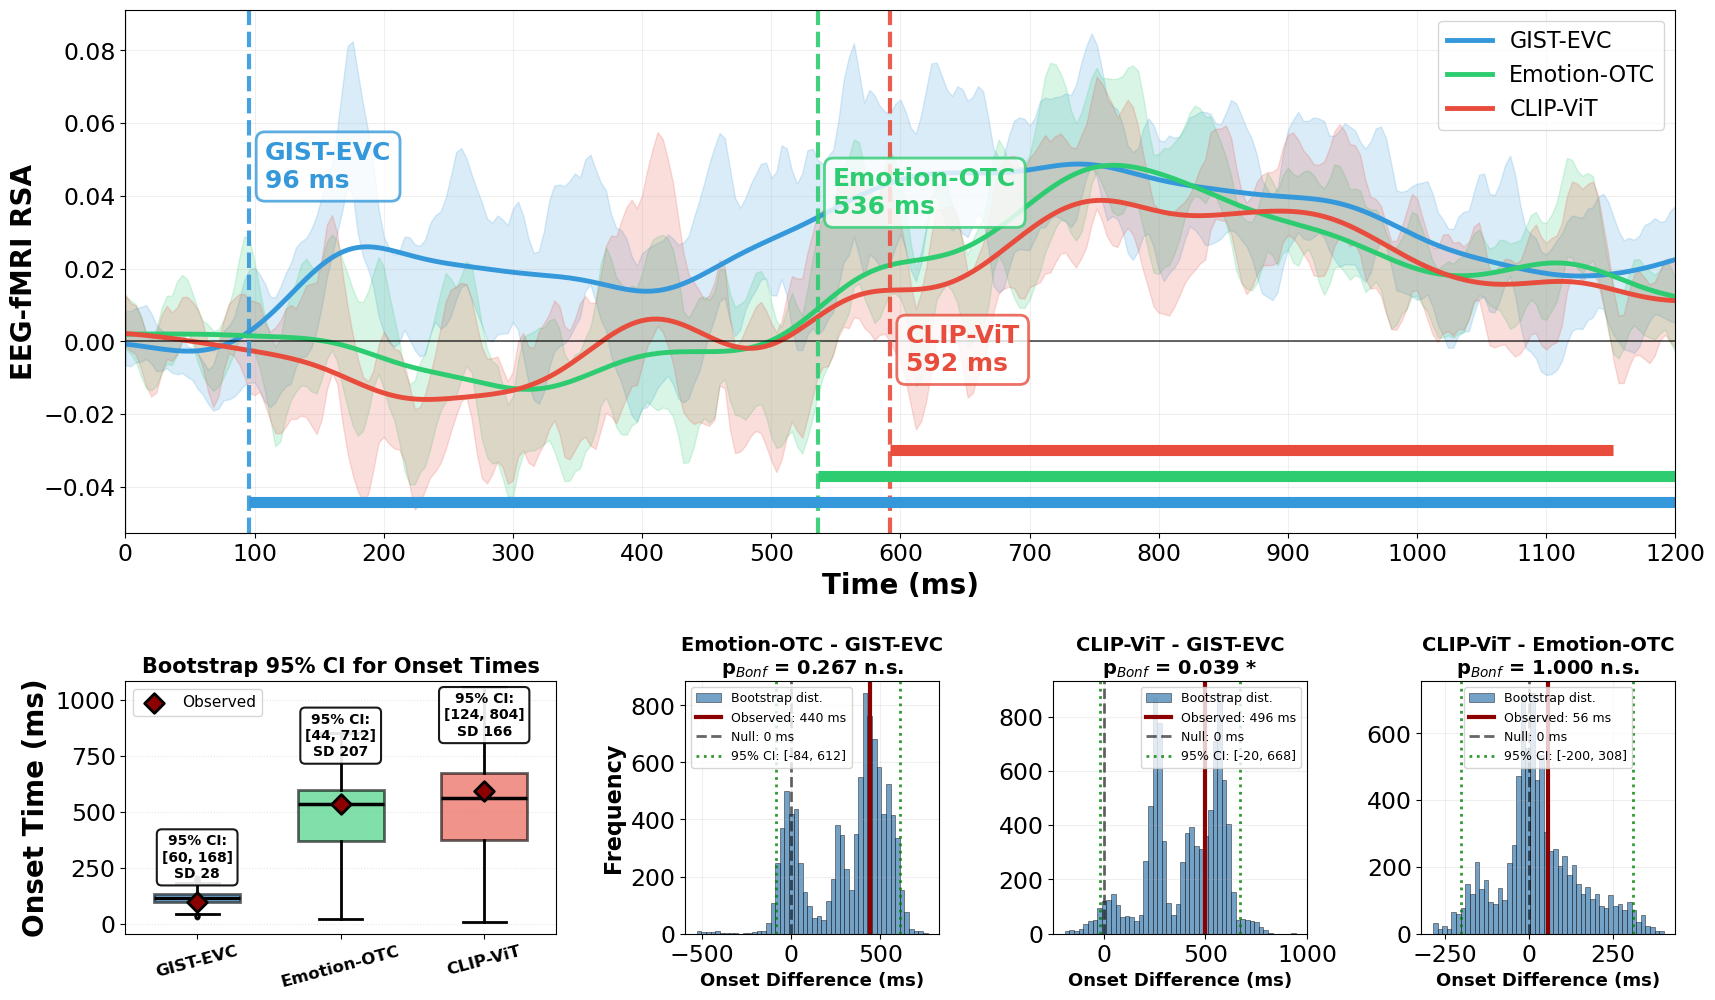

Saved: onset_main_configurable_thr5_smooth10_min5_boot10000\combined_onset_figure_bonf_perm_resized.png
Saved: onset_main_configurable_thr5_smooth10_min5_boot10000\combined_onset_figure_bonf_perm_resized.pdf


In [33]:
# ============================================================
# FIGURE
# ============================================================
plt.rcParams.update({
    "font.size": 18,
    "axes.titlesize": 22,
    "axes.labelsize": 20,
    "xtick.labelsize": 17,
    "ytick.labelsize": 17,
    "legend.fontsize": 16
})

fig = plt.figure(figsize=(20, 12))

# First row taller, second row shorter; total figure height unchanged
gs = gridspec.GridSpec(
    2, 3,
    figure=fig,
    height_ratios=[1.45, 0.70],
    hspace=0.38,
    wspace=0.30
)

axA = fig.add_subplot(gs[0, :])
axB = fig.add_subplot(gs[1, 0])

gsC = gridspec.GridSpecFromSubplotSpec(
    1, 3,
    subplot_spec=gs[1, 1:],
    wspace=0.45
)

axC = [fig.add_subplot(gsC[0, j]) for j in range(3)]

# --- Panel A ---
pmask = (x_shifted >= test_window[0]) & (x_shifted <= test_window[1])
xp = x_shifted[pmask]

label_y_frac = {
    "GIST-EVC": 0.75,
    "Emotion-OTC": 0.70,
    "Scene-ClipViT": 0.40
}

for name in condition_names:
    r = onset_results[name]

    axA.plot(
        xp,
        r["smoothed_bc"][pmask],
        color=colors[name],
        linewidth=3.5,
        label=disp(name)
    )

    axA.fill_between(
        xp,
        r["mean_curve_bc"][pmask] - r["sem_curve_bc"][pmask],
        r["mean_curve_bc"][pmask] + r["sem_curve_bc"][pmask],
        color=colors[name],
        alpha=0.18
    )

axA.axhline(0, color="black", linewidth=1.2, alpha=0.7)

ymin, ymax = axA.get_ylim()

for name in condition_names:
    o = onset_results[name]["onset_time"]

    if not np.isnan(o):
        axA.axvline(
            o,
            color=colors[name],
            linestyle="--",
            linewidth=3,
            alpha=0.9
        )

        axA.text(
            o + 12,
            ymin + label_y_frac[name] * (ymax - ymin),
            f"{disp(name)}\n{o:.0f} ms",
            color=colors[name],
            fontsize=18,
            fontweight="bold",
            va="top",
            ha="left",
            bbox=dict(
                boxstyle="round,pad=0.35",
                facecolor="white",
                edgecolor=colors[name],
                linewidth=2,
                alpha=0.8
            )
        )

yrange = ymax - ymin

bar_ys = {
    "GIST-EVC": ymin + 0.06 * yrange,
    "Emotion-OTC": ymin + 0.11 * yrange,
    "Scene-ClipViT": ymin + 0.16 * yrange
}

for name in condition_names:
    for cl in onset_results[name].get("clusters", []):
        seg = cl[
            (x_shifted[cl] >= test_window[0]) &
            (x_shifted[cl] <= test_window[1])
        ]

        if len(seg):
            axA.plot(
                x_shifted[seg],
                np.full(len(seg), bar_ys[name]),
                color=colors[name],
                linewidth=8,
                solid_capstyle="butt"
            )

axA.axvline(0, color="black", linewidth=1.6, alpha=0.6)
axA.set_xlim(test_window)
axA.set_ylim(ymin, ymax)
axA.set_xticks(np.arange(test_window[0], test_window[1] + 1, 100))
axA.set_xlabel("Time (ms)", fontweight="bold")
axA.set_ylabel("EEG-fMRI RSA", fontweight="bold")
axA.legend(loc="upper right", frameon=True)
axA.grid(alpha=0.2)

# --- Panel B ---
onset_dists = [
    remove_outliers_iqr(bootstrap_results[n]["valid_onsets"])
    for n in condition_names
]

box = axB.boxplot(
    onset_dists,
    tick_labels=[disp(n) for n in condition_names],
    patch_artist=True,
    widths=0.6,
    showfliers=True,
    boxprops=dict(linewidth=2),
    whiskerprops=dict(linewidth=2),
    capprops=dict(linewidth=2),
    medianprops=dict(color="black", linewidth=2.5),
    flierprops=dict(marker="o", markersize=3, alpha=0.4)
)

for patch, name in zip(box["boxes"], condition_names):
    patch.set_facecolor(colors[name])
    patch.set_alpha(0.6)

observed = [onset_results[n]["onset_time"] for n in condition_names]

axB.scatter(
    [1, 2, 3],
    observed,
    color="darkred",
    s=100,
    zorder=5,
    marker="D",
    edgecolors="black",
    linewidths=2,
    label="Observed"
)

for i, (name, dist) in enumerate(zip(condition_names, onset_dists)):
    lo, hi = np.percentile(dist, [2.5, 97.5])
    sd = dist.std(ddof=1)

    axB.text(
        i + 1,
        hi + 25,
        f"95% CI:\n[{lo:.0f}, {hi:.0f}]\nSD {sd:.0f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="black",
            alpha=0.9,
            linewidth=1.5
        )
    )

axB.set_ylim(top=max(np.percentile(d, 97.5) for d in onset_dists) * 1.35)
axB.set_title(
    "Bootstrap 95% CI for Onset Times",
    fontsize=15,
    fontweight="bold",
    pad=6
)
axB.set_ylabel("Onset Time (ms)", fontweight="bold")
axB.legend(loc="upper left", frameon=True, fontsize=11)
axB.grid(axis="y", alpha=0.3, linestyle=":")
axB.tick_params(axis="x", labelrotation=15, labelsize=12)

for lbl in axB.get_xticklabels():
    lbl.set_fontweight("bold")

# --- Panel C ---
for j, key in enumerate(panelC):
    ax = axC[j]
    res = panelC[key]

    diffs = res["bdiffs"]
    ci = res["ci"]
    obs = res["obs"]
    p = res["p"]

    sig = "*" if p < ALPHA else "n.s."

    ax.hist(
        diffs,
        bins=50,
        color="steelblue",
        alpha=0.75,
        edgecolor="black",
        linewidth=0.4,
        label="Bootstrap dist."
    )

    ax.axvline(
        obs,
        color="darkred",
        linewidth=3,
        label=f"Observed: {obs:.0f} ms"
    )

    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=2,
        alpha=0.6,
        label="Null: 0 ms"
    )

    ax.axvline(
        ci[0],
        color="green",
        linestyle=":",
        linewidth=2,
        alpha=0.8
    )

    ax.axvline(
        ci[1],
        color="green",
        linestyle=":",
        linewidth=2,
        alpha=0.8,
        label=f"95% CI: [{ci[0]:.0f}, {ci[1]:.0f}]"
    )

    ax.set_title(
        f"{disp_comparison(key)}\n" + r"p$_{Bonf}$" + f" = {p:.3f} {sig}",
        fontsize=14,
        fontweight="bold",
        pad=5
    )

    ax.set_xlabel("Onset Difference (ms)", fontsize=13, fontweight="bold")

    if j == 0:
        ax.set_ylabel("Frequency", fontsize=16, fontweight="bold")

    ax.legend(fontsize=9)
    ax.grid(alpha=0.2)

# Save
os.makedirs(out_dir, exist_ok=True)

out_png = os.path.join(out_dir, "combined_onset_figure_bonf_perm_resized.png")
out_pdf = os.path.join(out_dir, "combined_onset_figure_bonf_perm_resized.pdf")

fig.savefig(out_png, dpi=300, bbox_inches="tight")
fig.savefig(out_pdf, bbox_inches="tight")

plt.show()

print("Saved:", out_png)
print("Saved:", out_pdf)